## combinatorial strategy

In [1]:
fpath = r"D:\Rumbaugh_e19_60X_targetoverview_projection_t0_B03_s0_w0_z0.tif"

## cropping extraction functions

In [2]:
import os
import glob
import re
import numpy as np
import tifffile
import roifile
import concurrent.futures

import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import scipy

def parse_filepath_attributes(file_path):
    # Convert string to a Path object to easily isolate folders
    path_parts = Path(file_path).parts
    
    dendrite_type = None
    slide_element = None
    slide_id = None
    
    # 1. Extract dendrite type (basal vs tuft)
    # Checking against the raw string so it catches it anywhere in the path
    if "basal" in file_path:
        dendrite_type = "basal"
    elif "tuft" in file_path:
        dendrite_type = "tuft"
        
    # 2. Extract Slide element and ID
    if "Slide" in file_path:
        # Loop through the isolated folders to find the one containing "Slide"
        for part in path_parts:
            if "Slide" in part:
                slide_element = part  # Captures the full folder name: "Slide8_well2"
                
                # Use regex to extract just the number immediately following "Slide"
                match = re.search(r'Slide(\d+)', part)
                if match:
                    slide_id = int(match.group(1))  # Captures the ID: 8
                break # Stop searching once we find the Slide folder

    return {
        "dendrite_type": dendrite_type,
        "slide_element": slide_element,
        "slide_id": slide_id
    }

def view_stack_jupyter(volume, level=176, window=67, title="Z-Stack Viewer"):


    """
    Creates a Jupyter-native interactive slider to scroll through a 3D Z-stack.
    Applies specified Window and Level for contrast.
    
    Parameters:
    - volume: 3D numpy array (Z, Y, X).
    - level: Window center for contrast.
    - window: Window width for contrast.
    - title: Optional string to display above the plot.
    """
    if volume is None or not isinstance(volume, np.ndarray):
        print("Please provide a valid 3D numpy array.")
        return

    z_dim = volume.shape[0]
    
    # Calculate contrast limits based on Window and Level
    vmin = level - (window / 2.0)
    vmax = level + (window / 2.0)

    # The plotting function that ipywidgets will call on every slider move
    def plot_slice(z_index):
        plt.figure(figsize=(10, 8))
        plt.imshow(volume[z_index], cmap='gray', vmin=vmin, vmax=vmax)
        plt.title(f"{title} | Z-Slice: {z_index} / {z_dim - 1} | L:{level} W:{window}")
        plt.axis('off')
        plt.show()

    # Generate the interactive slider UI
    slider = widgets.IntSlider(
        min=0, 
        max=z_dim - 1, 
        step=1, 
        value=0, 
        description='Z-Slice:',
        continuous_update=False  # Prevents notebook lag while dragging
    )
    
    # Bind the slider to the plotting function
    widgets.interact(plot_slice, z_index=slider)

def plot_intensity_histogram(volume, range1=(20, 50), range2=(220, 250), 
                             bins=100, method='percentile', percentile_val=95):
    """
    Calculates a projection (mean or percentile) for two Z-ranges and plots their histograms.
    
    Parameters:
    - volume: 3D numpy array (Z, Y, X).
    - range1: Tuple of (start_z, end_z) for the first block.
    - range2: Tuple of (start_z, end_z) for the second block.
    - bins: Number of histogram bins.
    - method: 'mean' or 'percentile'.
    - percentile_val: The percentile to calculate (0-100) if method='percentile'.
    """
    if volume is None or not isinstance(volume, np.ndarray):
        print("Please provide a valid 3D numpy array.")
        return

    # 1. Slice the 3D volume
    block1 = volume[range1[0] : range1[1] + 1]
    block2 = volume[range2[0] : range2[1] + 1]
    
    # 2. Apply the chosen projection method along the Z-axis (axis=0)
    if method == 'mean':
        proj1 = np.mean(block1, axis=0)
        proj2 = np.mean(block2, axis=0)
        title_prefix = "Mean"
    elif method == 'percentile':
        proj1 = np.percentile(block1, percentile_val, axis=0)
        proj2 = np.percentile(block2, percentile_val, axis=0)
        title_prefix = f"{percentile_val}th Percentile"
    else:
        print("Error: method must be either 'mean' or 'percentile'.")
        return
        
    # 3. Flatten the 2D images into 1D arrays for the histogram
    pixels1 = proj1.flatten()
    pixels2 = proj2.flatten()
    
    # 4. Plot the histograms
    plt.figure(figsize=(10, 6))
    
    plt.hist(pixels1, bins=bins, alpha=0.6, color='blue', label=f'Z-slices {range1[0]}-{range1[1]}')
    plt.hist(pixels2, bins=bins, alpha=0.6, color='orange', label=f'Z-slices {range2[0]}-{range2[1]}')
    
    plt.title(f'Histogram of {title_prefix} Pixel Intensities')
    plt.xlabel(f'{title_prefix} Pixel Intensity')
    plt.ylabel('Frequency (Pixel Count)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    # Optional: Uncomment if the background peak hides your signal distribution
    # plt.yscale('log') 
    
    plt.show()

def plot_z_signal_profile(volume, percentile_val=90):
    """
    Plots the sum of all pixels at or above a given percentile for every Z-slice.
    This creates a signal intensity profile across the depth of the Z-stack.
    
    Parameters:
    - volume: 3D numpy array (Z, Y, X).
    - percentile_val: The percentile threshold (0-100).
    """
    if volume is None or not isinstance(volume, np.ndarray):
        print("Please provide a valid 3D numpy array.")
        return

    print(f"Calculating the global {percentile_val}th percentile threshold...")
    # 1. Calculate the global threshold for the entire 3D volume
    threshold = np.percentile(volume, percentile_val)
    print(f"Threshold value: {threshold:.2f}")
    
    # 2. Create a mask that zeros out anything below the threshold
    # np.where(condition, true_yield, false_yield)
    masked_volume = np.where(volume >= threshold, volume, 0)
    
    # 3. Sum the remaining (bright) pixels for each individual Z-slice
    # axis=(1, 2) means it sums across the Y and X dimensions, leaving a 1D array of length Z
    z_sums = np.sum(masked_volume, axis=(1, 2))
    
    # 4. Plot the signal profile across the Z-axis
    z_slices = np.arange(len(z_sums))
    
    plt.figure(figsize=(12, 6))
    plt.plot(z_slices, z_sums, color='green', linewidth=2)
    
    # Fill the area under the curve for better visual impact
    plt.fill_between(z_slices, z_sums, color='green', alpha=0.2)
    
    plt.title(f'Signal Profile Across Z-Axis (Sum of Top {100 - percentile_val}% Pixels)')
    plt.xlabel('Z-Slice Index')
    plt.ylabel('Sum of Bright Pixels')
    plt.grid(True, alpha=0.3)
    
    plt.xlim(0, len(z_sums) - 1)
    plt.ylim(bottom=0) # Ensure the Y-axis always starts at 0
    
    plt.show()

class ZStackProcessor:
    # Added roi_zip_path to the signature so it doesn't throw a NameError
    def __init__(self, base_dir_path):
        """
        Initializes the processor with paths to the required files.
        """
        # Assuming parse_filepath_attributes is defined elsewhere in your code
        properties = parse_filepath_attributes(base_dir_path)

        # Grabbing the first file for projection (adjust if your projection has a specific name)
        self.z_proj_path = glob.glob(f'{base_dir_path}/experiment/*/*.tif')[0]
        
        # This creates a list of all matching file paths
        self.z_stack_files = glob.glob(f'{base_dir_path}/experiment_z_stack/*/*.tif')
        self.roi_zip_path = glob.glob(f'{base_dir_path}/*.zip')[0]
        self.outpath = f'{base_dir_path}/outputdir'
        
        self.z_stack = None
        self.z_proj = None
        self.rois = None

        self.dendrite_type = properties['dendrite_type']
        self.slide = properties['slide_element']
        
        # Fixed duplicate xpixdim
        self.xpixdim = 0.108
        self.ypixdim = 0.108 
        self.zpixdim = 0.3
    
    def _get_z_index(self, filepath):
        """
        Helper method to extract the integer after '_z' in the filename.
        e.g., 'image_z2.tif' -> 2, 'image_z100.tif' -> 100
        """
        match = re.search(r'_z(\d+)', filepath)
        if match:
            return int(match.group(1))
        # Fallback if no '_z' is found, puts it at the start
        return -1 

    def _read_single_slice(self, index, filepath):
        """
        Worker function for the thread pool to read an image 
        and place it directly into the pre-allocated array.
        """
        self.z_stack[index, :, :] = tifffile.imread(filepath)

    def load_files(self):
        """
        Sorts files, pre-allocates memory, and loads Z-slices concurrently.
        """
        if not self.z_stack_files:
            raise ValueError("No Z-stack files were found during initialization.")

        print(f"Sorting and loading {len(self.z_stack_files)} Z-Stack images...")
        
        # 1. Sort the list using our custom regex function
        self.z_stack_files.sort(key=self._get_z_index)
        
        # 2. Read the first slice to determine shape and data type
        first_slice = tifffile.imread(self.z_stack_files[0])
        z_dim = len(self.z_stack_files)
        y_dim, x_dim = first_slice.shape
        
        # 3. Pre-allocate the full 3D array (saves memory and stacking time)
        self.z_stack = np.empty((z_dim, y_dim, x_dim), dtype=first_slice.dtype)
        
        # Insert the first slice since we already read it
        self.z_stack[0, :, :] = first_slice
        
        # 4. Multithread the loading of the remaining files
        print("Reading files concurrently from disk...")
        with concurrent.futures.ThreadPoolExecutor() as executor:
            # We skip index 0 since we already loaded it
            futures = [
                executor.submit(self._read_single_slice, i, self.z_stack_files[i]) 
                for i in range(1, z_dim)
            ]
            # Wait for all threads to finish
            concurrent.futures.wait(futures)
            
        print(f"Constructed Z-Stack volume with shape: {self.z_stack.shape}")
        
        print("Loading Z-Projection...")
        self.z_proj = tifffile.imread(self.z_proj_path)
        
        print("Loading ROIs...")
        self.rois = roifile.roiread(self.roi_zip_path)

    def plot_rois_on_projection(self, figsize=(12, 12), line_color='red', 
                                vmin=None, vmax=None, level=176, window=67):
        """
        Plots the Z-projection with ROIs.
        Accepts EITHER vmin/vmax directly OR level/window.
        """
        import matplotlib.pyplot as plt

        if self.z_proj is None or self.rois is None:
            print("Data not loaded. Loading files first...")
            self.load_files()

        # If Level and Window are provided, convert them to vmin/vmax
        if level is not None and window is not None:
            vmin = level - (window / 2.0)
            vmax = level + (window / 2.0)
            
        # Fallback: if nothing is provided, use the image's actual min/max
        if vmin is None or vmax is None:
            vmin = np.min(self.z_proj)
            vmax = np.max(self.z_proj)

        plt.figure(figsize=figsize)
        
        # Apply the contrast limits
        plt.imshow(self.z_proj, cmap='gray', vmin=vmin, vmax=vmax)

        for i, roi in enumerate(self.rois):
            coords = roi.coordinates()
            if coords is not None and len(coords) > 0:
                x = np.append(coords[:, 0], coords[0, 0])
                y = np.append(coords[:, 1], coords[0, 1])
                
                plt.plot(x, y, color=line_color, linewidth=1.5)
                plt.text(roi.left, roi.top - 5, f"ROI {i+1}", 
                         color='yellow', fontsize=10, weight='bold')

        title_str = f"Slide: {self.slide} | Type: {self.dendrite_type}"
        if level and window:
            title_str += f" | L:{level} W:{window}"
        else:
            title_str += f" | Min:{vmin} Max:{vmax}"
            
        plt.title(title_str)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
    def extract_subvolumes(self, percentile_val=99, min_prominence_ratio=0.05, peak_rel_height=0.85, z_buffer=2, roi_index=None):
        """
        Crops the Z-stack in XY using the ROIs, then crops in Z based on the 
        prominence of the signal peak (sum of top percentile pixels).
        """

        if self.z_stack is None:
            self.load_files()
        output_dir = self.outpath

        os.makedirs(output_dir, exist_ok=True)
        max_z, max_y, max_x = self.z_stack.shape

        for i, roi in enumerate(self.rois):
            # If a specific roi_index is provided, skip all others
            if roi_index is not None and i != roi_index:
                continue

            # 1. Get XY bounding box from the ROI
            y1 = max(0, int(roi.top))
            y2 = min(max_y, int(roi.bottom))
            x1 = max(0, int(roi.left))
            x2 = min(max_x, int(roi.right))

            # 2. Crop the full Z-stack in X and Y
            xy_cropped_stack = self.z_stack[:, y1:y2, x1:x2]

            # 3. Z-Cropping Logic based on Peak Prominence
            # Force percentile_val to a float to prevent NumPy strict casting errors
            pixel_threshold = np.percentile(xy_cropped_stack, float(percentile_val))
            
            # Mask out the background (set anything below the threshold to 0)
            masked_volume = np.where(xy_cropped_stack >= pixel_threshold, xy_cropped_stack, 0)
            
            # Sum the surviving bright pixels for each Z-slice
            z_sums = np.sum(masked_volume, axis=(1, 2))
            
            # Find all peaks in the signal.
            min_prominence = np.max(z_sums) * min_prominence_ratio
            peaks, properties = scipy.signal.find_peaks(z_sums, prominence=min_prominence)

            if len(peaks) == 0:
                print(f"ROI {i+1}: No distinct signal peaks found. Skipping.")
                continue

            # Identify the single most prominent peak
            best_peak_idx = np.argmax(properties["prominences"])
            best_peak = peaks[best_peak_idx]

            # Calculate the width of this specific peak near its base
            widths, width_heights, left_ips, right_ips = scipy.signal.peak_widths(
                z_sums, [best_peak], rel_height=peak_rel_height
            )

            # Convert the interpolated left/right edges to integer Z-indices
            detected_start = int(left_ips[0])
            detected_end = int(right_ips[0])

            # 4. Apply the Z-buffer and clamp to valid Z-stack boundaries
            start_z = max(0, detected_start - z_buffer)
            end_z = min(max_z, detected_end + z_buffer + 1) 

            # 5. Final 3D Crop
            final_crop = xy_cropped_stack[start_z:end_z, :, :]

            # 6. Save the resulting sub-volume
            out_filename = f"{self.slide}_{self.dendrite_type}_ROI_{i+1}_Z{start_z}-{end_z-1}.tif"
            out_path = os.path.join(output_dir, out_filename)
            
            # Save using tifffile
            tifffile.imwrite(
                out_path, 
                final_crop, 
                imagej=True,
                resolution=(1./self.xpixdim, 1./self.ypixdim),
                metadata={'spacing': self.zpixdim, 'unit': 'um'}
            )
            
            print(f"Saved {out_filename} (Shape: {final_crop.shape})")


## Functions

In [3]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import warnings
from skimage.filters import frangi, gaussian, apply_hysteresis_threshold
from skimage.morphology import remove_small_objects
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.spatial.distance import pdist, squareform
from skimage import morphology, filters, measure, graph
import tifffile
from scipy.spatial.distance import pdist, squareform, cdist

warnings.filterwarnings("ignore", category=FutureWarning)

def process_single_patch(patch_mip, global_otsu, min_cc_size=50, min_branch_length=10):
    """Processes a small image tile, rejecting patches that are purely background noise."""
    
    smoothed = filters.gaussian(patch_mip.astype(float), sigma=1.5)
    
    try:
        thresh = filters.threshold_li(smoothed)
    except Exception:
        return np.zeros_like(patch_mip, dtype=bool)
        
    binary_mask = smoothed > thresh
    
    # --- THE FIX: Foreground Fraction Rejection ---
    # If >25% of the patch is foreground, Li is hallucinating on background noise.
    # We only allow it to pass if the patch contains something exceptionally bright (like the soma).
    if np.mean(binary_mask) > 0.25 and patch_mip.max() < global_otsu:
        return np.zeros_like(patch_mip, dtype=bool)
        
    binary_mask = morphology.closing(binary_mask, morphology.disk(5))
    labeled = measure.label(binary_mask)
    
    local_edt = ndi.distance_transform_edt(binary_mask)
    patch_reconstructed = np.zeros_like(patch_mip, dtype=bool)
    Y, X = np.indices(patch_mip.shape)
    
    for region in measure.regionprops(labeled):
        if region.area < min_cc_size:
            continue 
            
        comp_mask = (labeled == region.label)
        skel = morphology.skeletonize(comp_mask)
        
        kernel = np.array([[1, 1, 1], [1, 10, 1], [1, 1, 1]])
        neighbor_count = ndi.convolve(skel.astype(int), kernel, mode='constant')
        endpoints = np.argwhere((neighbor_count == 11) & skel)
        
        if len(endpoints) < 2:
            continue 
            
        D = squareform(pdist(endpoints))
        i, j = np.unravel_index(np.argmax(D), D.shape)
        start_pt, end_pt = tuple(endpoints[i]), tuple(endpoints[j])
        
        cost_map = np.where(skel, 1, 1e6)
        
        try:
            main_path, _ = graph.route_through_array(cost_map, start=start_pt, end=end_pt, fully_connected=True)
        except ValueError:
            continue
            
        accepted_coords = list(main_path)
        set_accepted = set(main_path)
        remaining_endpoints = [tuple(ep) for idx, ep in enumerate(endpoints) if idx not in (i, j)]
        
        if remaining_endpoints:
            distances = cdist(remaining_endpoints, accepted_coords)
            min_dists = np.min(distances, axis=1)
            sorted_indices = np.argsort(min_dists)[::-1]
            
            for idx in sorted_indices:
                ep = remaining_endpoints[idx]
                dists_to_tree = cdist([ep], accepted_coords)[0]
                target_pt = tuple(accepted_coords[np.argmin(dists_to_tree)])
                
                try:
                    branch_path, _ = graph.route_through_array(cost_map, start=ep, end=target_pt, fully_connected=True)
                    new_pixels = set(branch_path) - set_accepted
                    if len(new_pixels) >= min_branch_length:
                        accepted_coords.extend(list(new_pixels))
                        set_accepted.update(new_pixels)
                except ValueError:
                    continue 
                    
        for r, c in accepted_coords:
            radius = local_edt[r, c]
            if radius > 0:
                circle = (Y - r)**2 + (X - c)**2 <= (radius + 0.5)**2
                patch_reconstructed |= circle
                
    return patch_reconstructed

def generate_hysteresis_mask(tiff_path):
    # 1. Load and Normalize
    with tifffile.TiffFile(tiff_path) as tif:
        valid_pages = [page.asarray() for page in tif.pages]
        volume = np.stack(valid_pages)
        
    mip = np.max(volume, axis=0) if volume.ndim == 3 else volume
    
    mip_float = mip.astype(np.float64)
    mip_norm = (mip_float - np.min(mip_float)) / (np.max(mip_float) - np.min(mip_float) + 1e-8)

    # 2. Smoothing & Frangi
    print("Running Frangi filter...")
    mip_smoothed = gaussian(mip_norm, sigma=1.5)
    vesselness = frangi(mip_smoothed, sigmas=np.arange(1, 10, 2), black_ridges=False)

    print("Applying Hysteresis Thresholding...")
    # 3. THE FIX: Hysteresis Thresholding
    # High threshold: Only the absolute brightest tracks (Top 2%)
    high_thresh = np.percentile(vesselness, 98.0)
    
    # Low threshold: The fainter secondary tracks (Top 6%)
    # If the faint tips are still cutting off, lower this to 93.0 or 92.0
    low_thresh = np.percentile(vesselness, 94.0)
    
    # Connect the high-confidence seeds along the low-confidence paths
    hysteresis_mask = apply_hysteresis_threshold(vesselness, low_thresh, high_thresh)

    print("Cleaning up...")
    # 4. Cleanup
    clean_binary_mask = remove_small_objects(hysteresis_mask, min_size=50)

    return mip, vesselness, clean_binary_mask


def reconstruct_by_tiling(tiff_path, patch_size=256, overlap=32):
    """
    Slices the image into overlapping patches, filtering out empty tiles.
    """
    with tifffile.TiffFile(tiff_path) as tif:
        valid_pages = [page.asarray() for page in tif.pages]
        volume = np.stack(valid_pages)
        
    mip = np.max(volume, axis=0) if volume.ndim == 3 else volume
    h, w = mip.shape
    
    # Calculate a global brightness benchmark to protect the soma
    smoothed_global = filters.gaussian(mip.astype(float), sigma=2.0)
    global_otsu = filters.threshold_otsu(smoothed_global)
    
    global_mask = np.zeros_like(mip, dtype=bool)
    step = patch_size - overlap
    
    for y in range(0, h, step):
        for x in range(0, w, step):
            y_start, y_end = max(0, y), min(h, y + patch_size)
            x_start, x_end = max(0, x), min(w, x + patch_size)
            
            local_mip = mip[y_start:y_end, x_start:x_end]
            
            # Pass the global_otsu benchmark into the patch processor
            local_mask = process_single_patch(local_mip, global_otsu)
            
            global_mask[y_start:y_end, x_start:x_end] |= local_mask

    return mip, global_mask

Running Frangi filter...
Applying Hysteresis Thresholding...
Cleaning up...


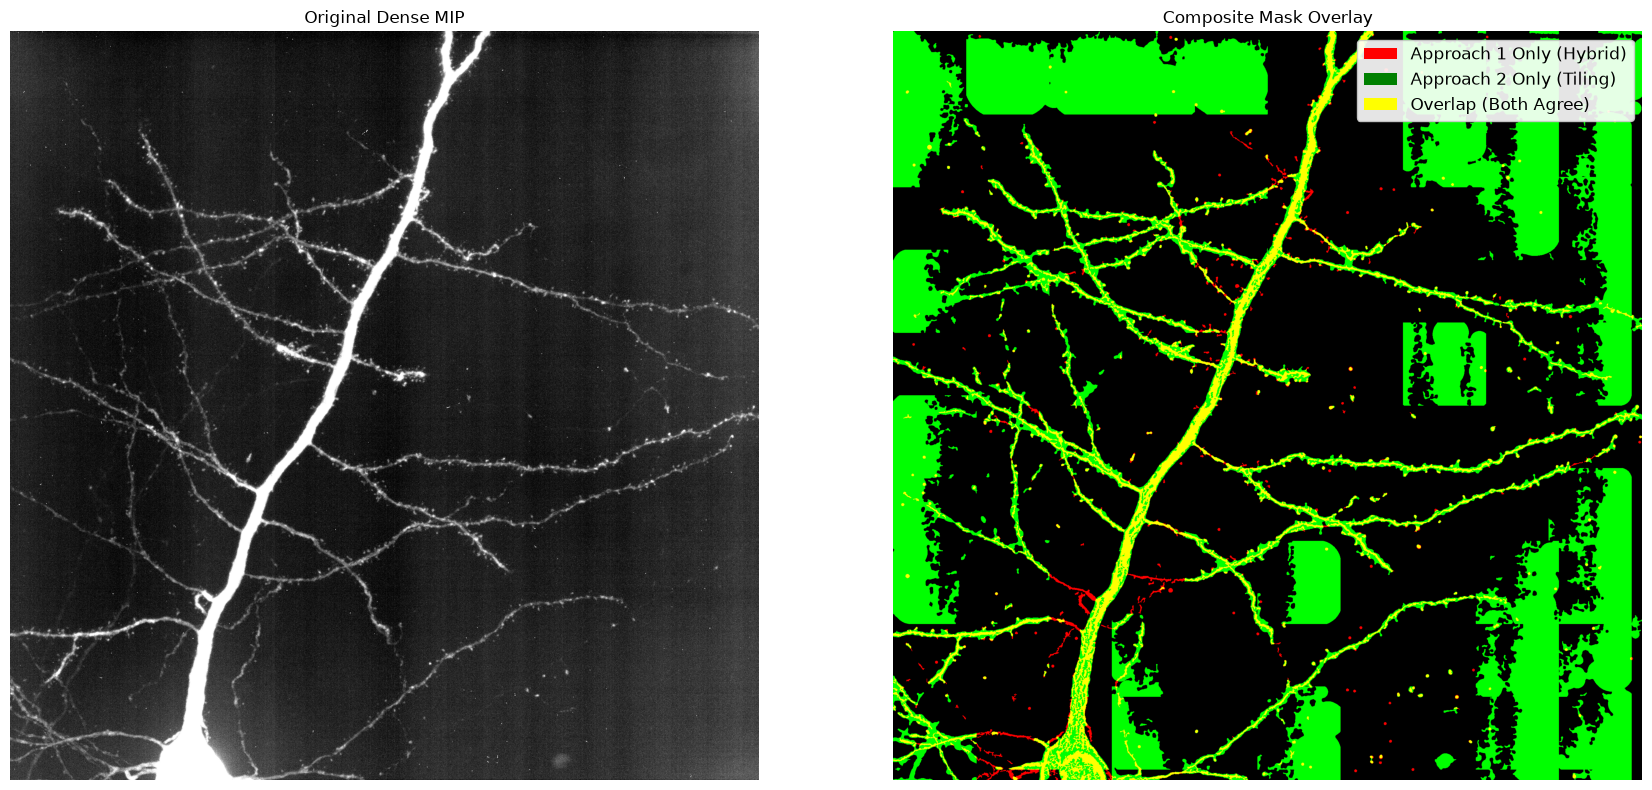

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Assuming 'mip', 'mask1' (Hybrid), and 'mask2' (Tiling) are already generated 
# using the functions you defined above:
mip, _, mask1 = generate_hysteresis_mask(fpath)
mip, mask2 = reconstruct_by_tiling(fpath)

# 1. Initialize an empty RGB image array (Height x Width x 3 channels)
h, w = mip.shape
composite_image = np.zeros((h, w, 3), dtype=np.float32)

# 2. Map the masks to the color channels
# Red Channel: Approach 1 (Hybrid Meijering)
composite_image[..., 0] = mask1 

# Green Channel: Approach 2 (Patch-Tiling Graph)
composite_image[..., 1] = mask2 

# The Blue channel remains completely empty (0).
# Math result:
# 1, 0, 0 = Pure Red (Only Hybrid captured it)
# 0, 1, 0 = Pure Green (Only Tiling captured it)
# 1, 1, 0 = Pure Yellow (Both algorithms agree)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Original Image
p_low, p_high = np.percentile(mip, 2), np.percentile(mip, 98)
axes[0].imshow(mip, cmap='gray', vmin=p_low, vmax=p_high)
axes[0].set_title('Original Dense MIP')
axes[0].axis('off')

# Plot 2: The Color-Coded Composite
axes[1].imshow(composite_image)
axes[1].set_title('Composite Mask Overlay')
axes[1].axis('off')

# Create a custom legend so the colors are instantly readable
legend_elements = [
    Patch(facecolor='red', label='Approach 1 Only (Hybrid)'),
    Patch(facecolor='green', label='Approach 2 Only (Tiling)'),
    Patch(facecolor='yellow', label='Overlap (Both Agree)')
]
axes[1].legend(handles=legend_elements, loc='upper right', framealpha=0.9, fontsize=12)

plt.tight_layout()
plt.show()

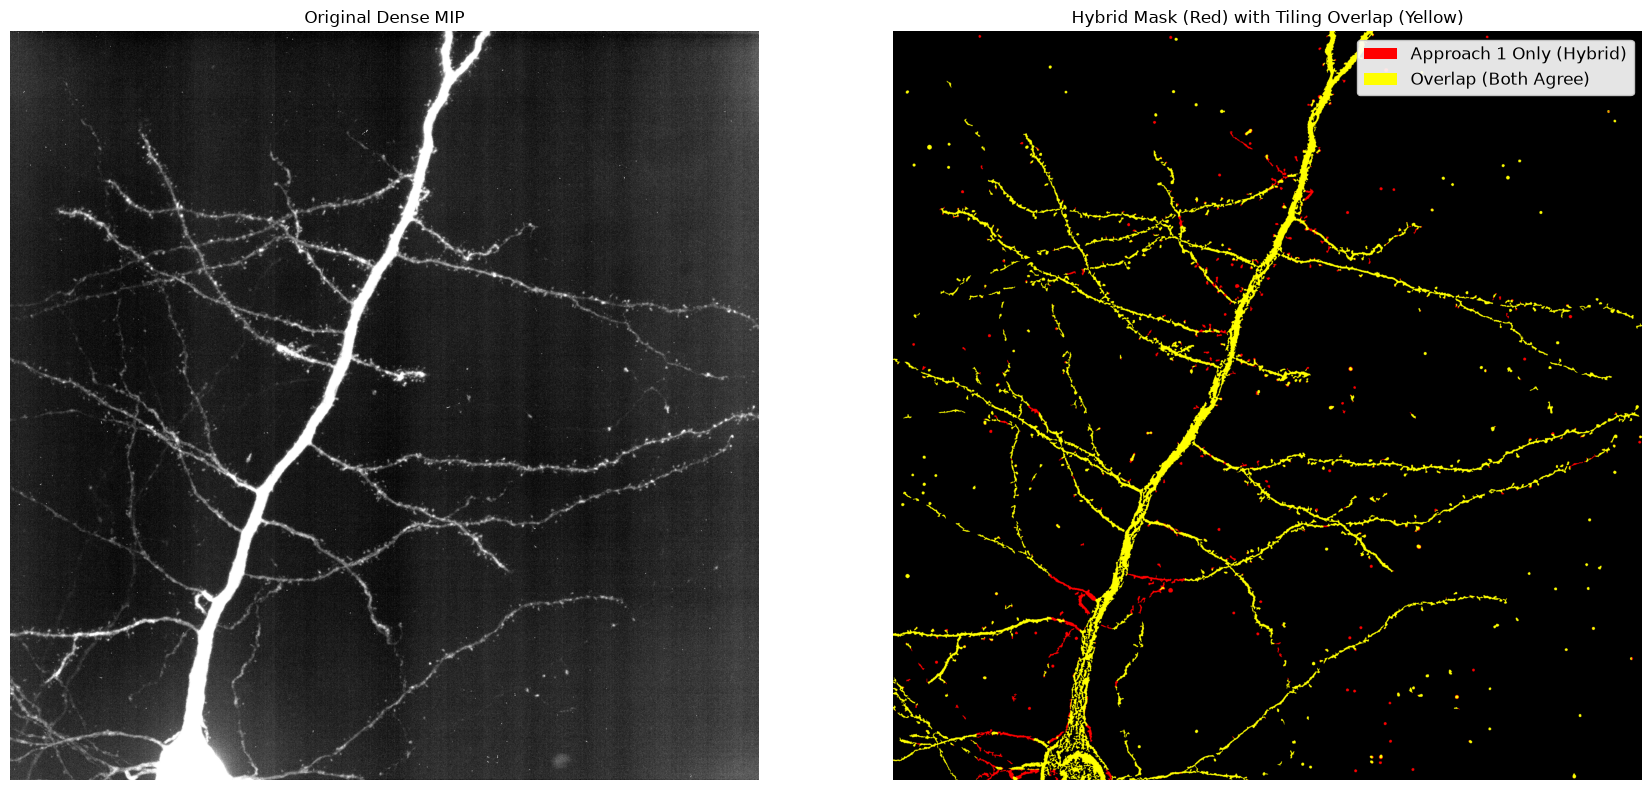

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Initialize an empty RGB image array (Height x Width x 3 channels)
h, w = mip.shape
composite_image = np.zeros((h, w, 3), dtype=np.float32)

# Red Channel: Approach 1 (Hybrid) is the baseline requirement to be visible
composite_image[..., 0] = mask1 

# Green Channel: Only activate if BOTH masks agree.
# Mixed with the Red channel, this creates the Yellow overlap.
# Because it requires mask1 to be True, pure Approach 2 pixels are excluded.
composite_image[..., 1] = mask1 & mask2 

# The Blue channel remains completely empty (0).

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Original Image
p_low, p_high = np.percentile(mip, 2), np.percentile(mip, 98)
axes[0].imshow(mip, cmap='gray', vmin=p_low, vmax=p_high)
axes[0].set_title('Original Dense MIP')
axes[0].axis('off')

# Plot 2: The Color-Coded Composite
axes[1].imshow(composite_image)
axes[1].set_title('Hybrid Mask (Red) with Tiling Overlap (Yellow)')
axes[1].axis('off')

# Custom legend updated to match the new color logic
legend_elements = [
    Patch(facecolor='red', label='Approach 1 Only (Hybrid)'),
    Patch(facecolor='yellow', label='Overlap (Both Agree)')
]
axes[1].legend(handles=legend_elements, loc='upper right', framealpha=0.9, fontsize=12)

plt.tight_layout()
plt.show()

Dilating and filling holes...
Removing background static...


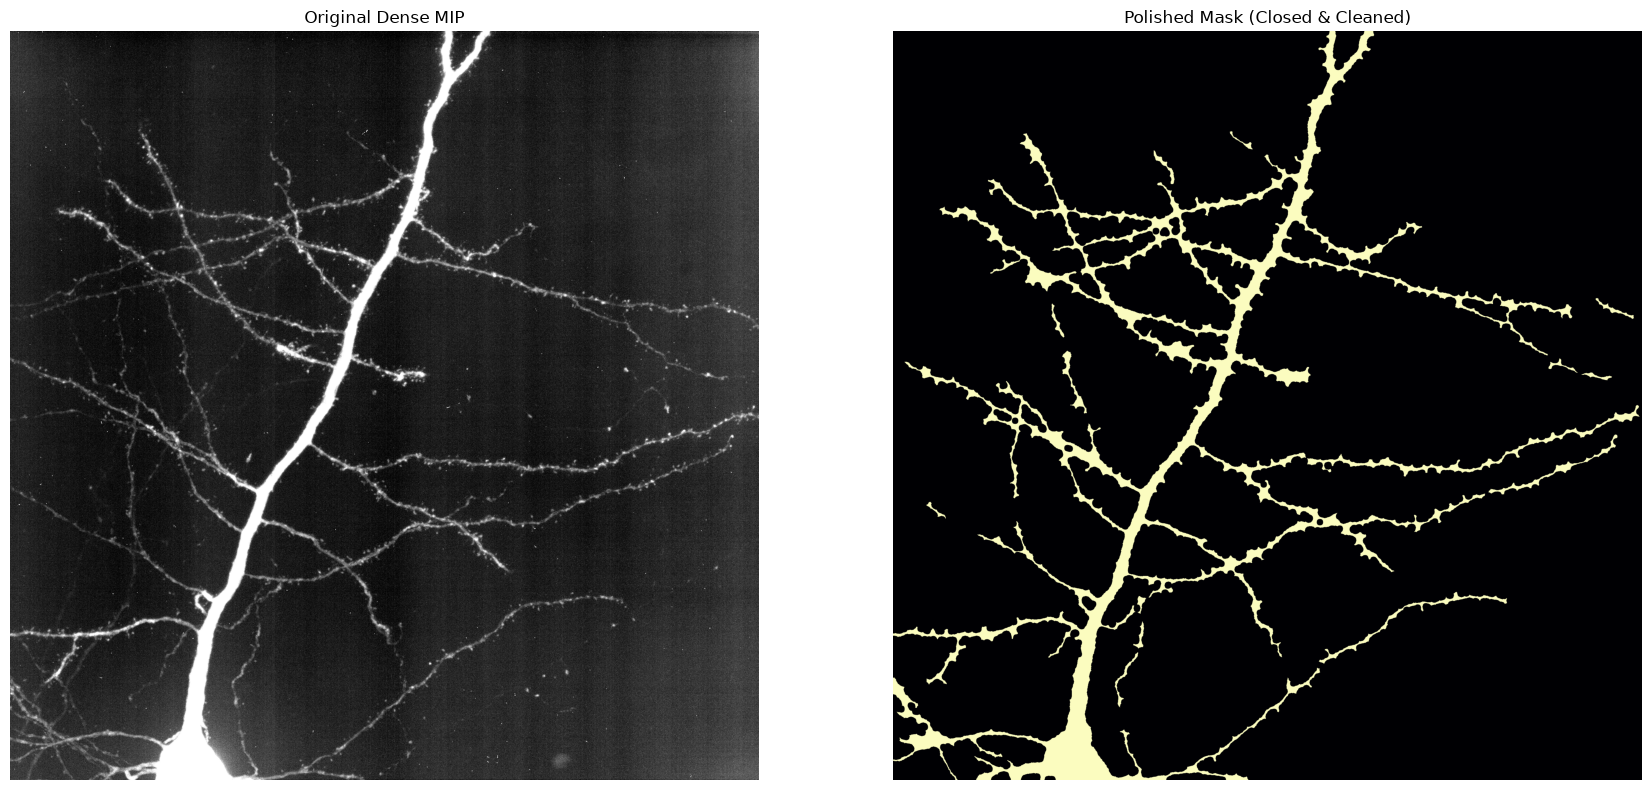

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from skimage.morphology import binary_closing, disk, remove_small_objects

# Ignore library deprecation warnings
warnings.filterwarnings("ignore", category=FutureWarning)

def polish_hybrid_mask(mip, mask1):
    # We completely discard mask2 (the tiling approach) to eliminate the square artifacts.
    # The Red and Yellow channels from the visualization represent mask1.
    
    print("Dilating and filling holes...")
    # 1. FILL HOLES (Morphological Closing)
    # disk(3) dilates the mask by 3 pixels to bridge the dashed gaps, 
    # then immediately erodes by 3 pixels to restore true dendrite thickness.
    closed_mask = binary_closing(mask1, disk(10))
    
    print("Removing background static...")
    # 2. CLEANUP
    # Wipe out the remaining floating noise chunks
    final_mask = remove_small_objects(closed_mask, min_size=500)
    
    return final_mask

# --- Execution ---

# Assuming 'mip' and 'mask1' (Hybrid Meijering output) are currently in memory
final_polished_mask = polish_hybrid_mask(mip, mask1)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

p_low, p_high = np.percentile(mip, 2), np.percentile(mip, 98)
axes[0].imshow(mip, cmap='gray', vmin=p_low, vmax=p_high)
axes[0].set_title('Original Dense MIP')
axes[0].axis('off')

axes[1].imshow(final_polished_mask, cmap='magma')
axes[1].set_title('Polished Mask (Closed & Cleaned)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Skeletonizing mask...
Pruning branches shorter than 100 pixels...
Locating true structural fork points...


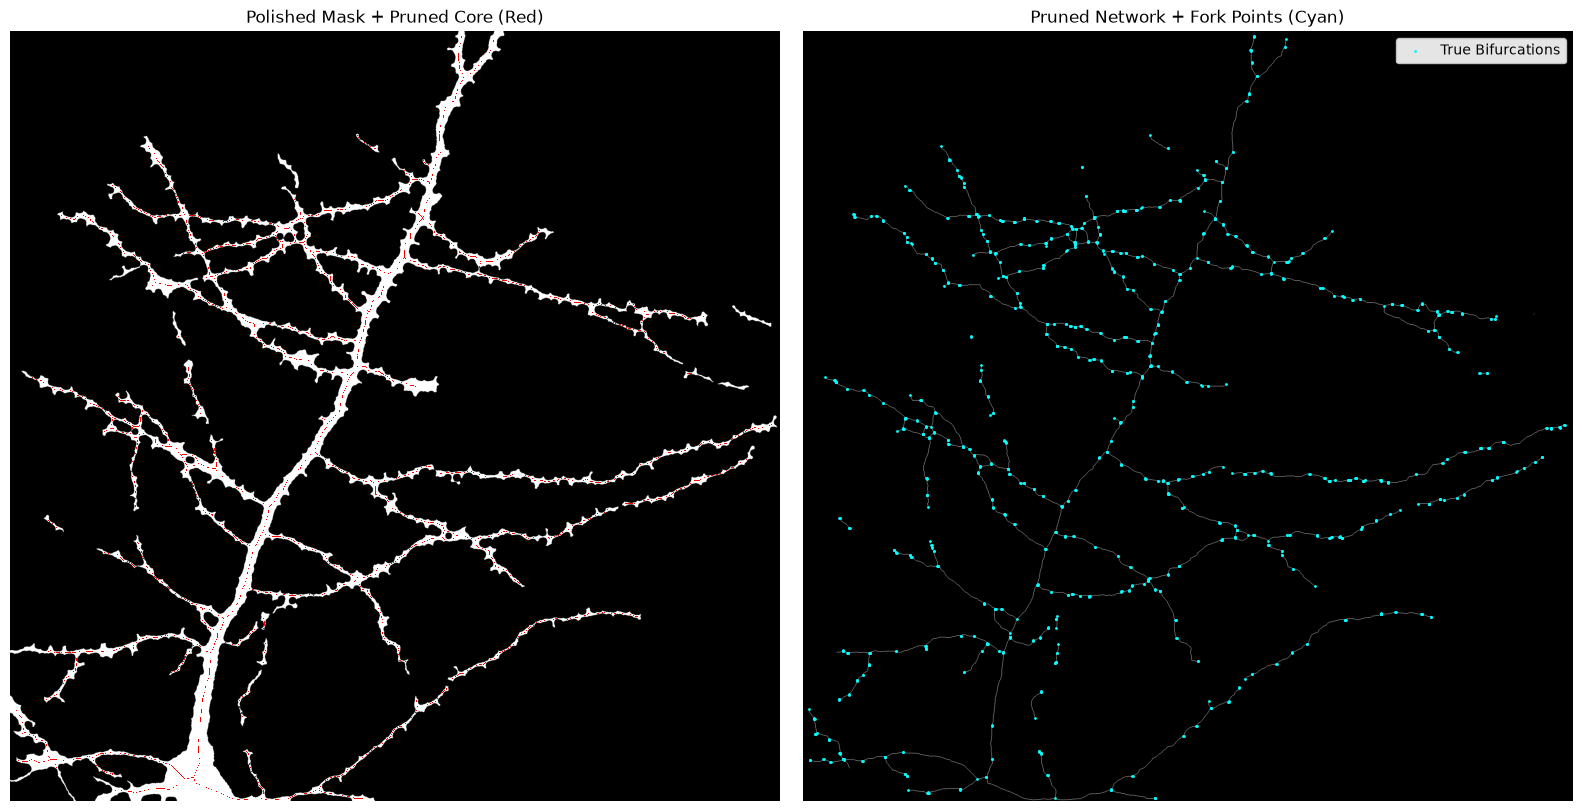

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from scipy.ndimage import convolve

def prune_skeleton_and_find_forks(binary_mask, prune_iterations=15):
    print("Skeletonizing mask...")
    raw_skeleton = skeletonize(binary_mask)
    
    print(f"Pruning branches shorter than {prune_iterations} pixels...")
    pruned_skeleton = raw_skeleton.copy()
    
    # Kernel: Center = 10, Neighbors = 1
    kernel = np.array([[1, 1, 1], 
                       [1, 10, 1], 
                       [1, 1, 1]])
    
    # Iteratively shave off endpoints
    for _ in range(prune_iterations):
        neighbor_count = convolve(pruned_skeleton.astype(int), kernel, mode='constant')
        # An endpoint has exactly 1 neighbor (10 + 1 = 11)
        endpoints = (neighbor_count == 11) & pruned_skeleton
        pruned_skeleton[endpoints] = False

    print("Locating true structural fork points...")
    # Recalculate neighbors on the clean, pruned skeleton
    final_neighbor_count = convolve(pruned_skeleton.astype(int), kernel, mode='constant')
    
    # Forks have 3 or more neighbors (10 + 3 = 13+)
    fork_points_mask = (final_neighbor_count >= 13) & pruned_skeleton
    fork_coords = np.argwhere(fork_points_mask)
    
    return pruned_skeleton, fork_coords

# --- Execution ---
# Assuming 'final_polished_mask' is currently in memory
# Adjust prune_iterations based on the maximum pixel length of your spines
clean_skeleton, true_forks = prune_skeleton_and_find_forks(final_polished_mask, prune_iterations=100)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: The Mask with the Pruned Skeleton Overlay
axes[0].imshow(final_polished_mask, cmap='gray')
skeleton_masked = np.ma.masked_where(~clean_skeleton, clean_skeleton)
axes[0].imshow(skeleton_masked, cmap='autumn', interpolation='none')
axes[0].set_title('Polished Mask + Pruned Core (Red)')
axes[0].axis('off')

# Plot 2: The Clean Network with True Fork Nodes
axes[1].imshow(clean_skeleton, cmap='gray')
axes[1].scatter(true_forks[:, 1], true_forks[:, 0], color='cyan', s=1, zorder=5, label='True Bifurcations')
axes[1].set_title('Pruned Network + Fork Points (Cyan)')
axes[1].legend(loc='upper right', framealpha=0.9)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Running convolution kernel...
Clustering topological nodes...
Collapsed noisy pixels down to 548 true bifurcations.


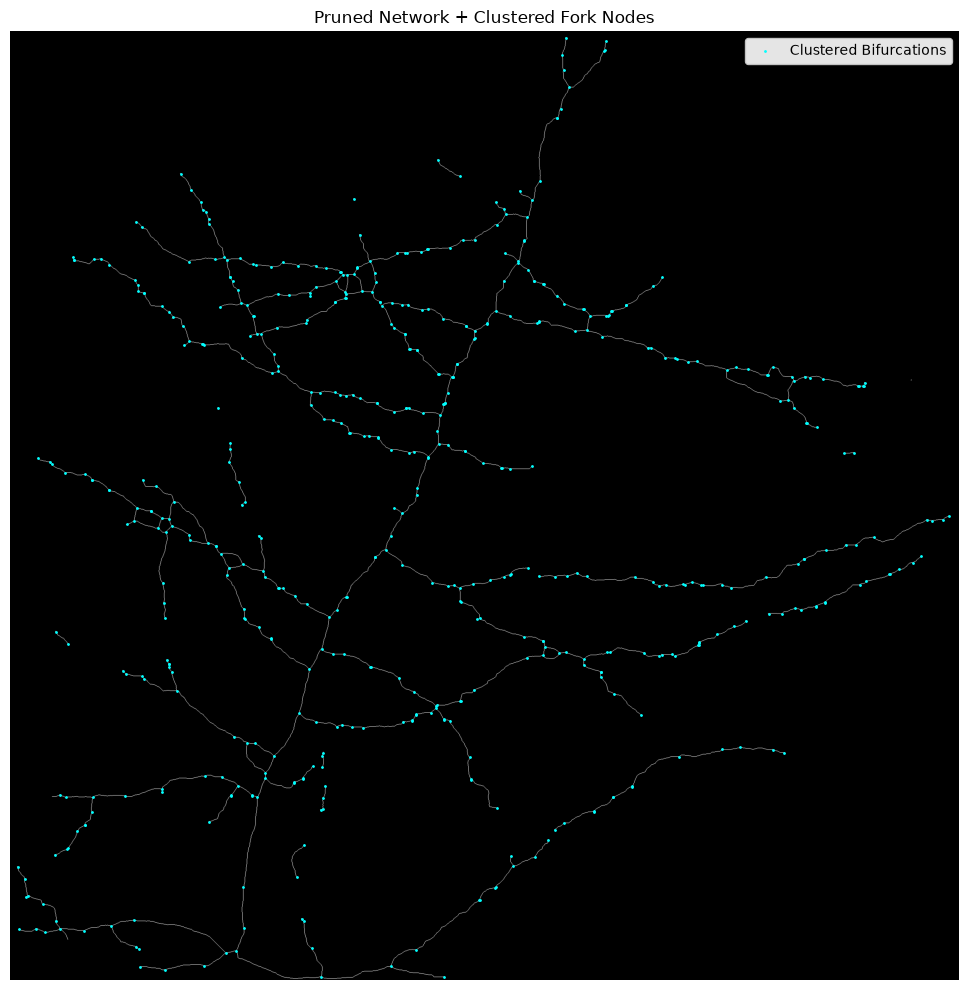

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from scipy.ndimage import convolve, label, center_of_mass

def get_true_bifurcations(clean_skeleton):
    print("Running convolution kernel...")
    # Kernel: Center = 10, Neighbors = 1
    kernel = np.array([[1, 1, 1], 
                       [1, 10, 1], 
                       [1, 1, 1]])
    
    neighbor_count = convolve(clean_skeleton.astype(int), kernel, mode='constant')
    
    # 1. Isolate the raw, noisy fork pixels
    raw_fork_mask = (neighbor_count >= 13) & clean_skeleton
    
    print("Clustering topological nodes...")
    # 2. THE FIX: Connected Components
    # Groups adjacent false-positive pixels into single identifiable clusters
    labeled_forks, num_forks = label(raw_fork_mask)
    
    # 3. Collapse the clusters
    # Calculates the exact center coordinate of every cluster
    centroids = center_of_mass(raw_fork_mask, labeled_forks, range(1, num_forks + 1))
    
    true_fork_coords = np.array(centroids)
    
    print(f"Collapsed noisy pixels down to {len(true_fork_coords)} true bifurcations.")
    return true_fork_coords

# --- Execution ---
# Pass your aggressively pruned skeleton into this new function
true_forks = get_true_bifurcations(clean_skeleton)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(clean_skeleton, cmap='gray')
ax.scatter(true_forks[:, 1], true_forks[:, 0], color='cyan', s=1, zorder=5, label='Clustered Bifurcations')
ax.set_title('Pruned Network + Clustered Fork Nodes')
ax.legend(loc='upper right', framealpha=0.9)
ax.axis('off')

plt.tight_layout()
plt.show()

Applying topological string-pull (Dilate -> Re-skeletonize)...
Running convolution kernel...
Clustering topological nodes...
Collapsed noisy pixels down to 102 true bifurcations.


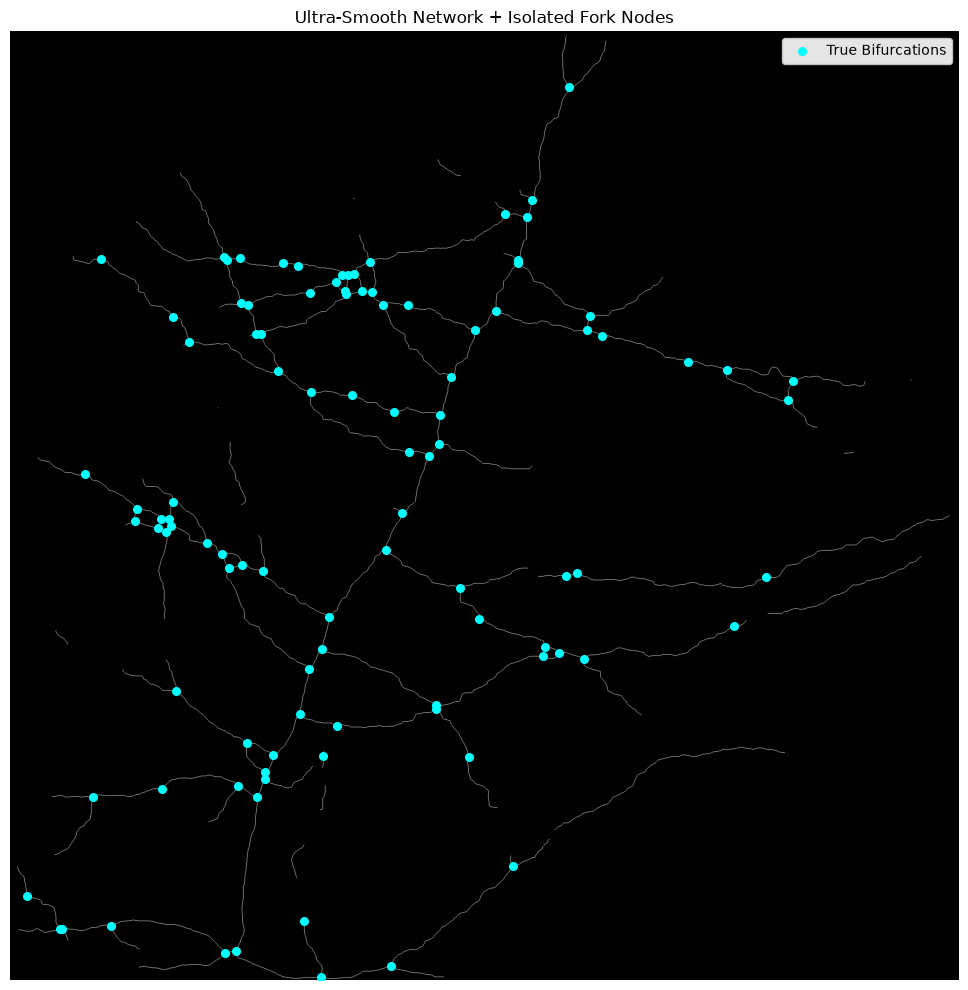

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize, binary_dilation, disk
from scipy.ndimage import convolve, label, center_of_mass

def dilate_reskeletonize_and_find_forks(pruned_skeleton):
    print("Applying topological string-pull (Dilate -> Re-skeletonize)...")
    
    # 1. INFLATE: Dilate the jagged skeleton into a uniform tube.
    # disk(3) provides a 6-pixel wide path, which is usually enough to swallow any micro-stubs.
    dilated_paths = binary_dilation(pruned_skeleton, disk(3))
    
    # 2. PULL TAUT: Find the pristine, dead-center line of the new smooth tubes.
    ultra_smooth_skeleton = skeletonize(dilated_paths)
    
    print("Running convolution kernel...")
    # Kernel: Center = 10, Neighbors = 1
    kernel = np.array([[1, 1, 1], 
                       [1, 10, 1], 
                       [1, 1, 1]])
    
    neighbor_count = convolve(ultra_smooth_skeleton.astype(int), kernel, mode='constant')
    
    # Isolate the raw, noisy fork pixels
    raw_fork_mask = (neighbor_count >= 13) & ultra_smooth_skeleton
    
    print("Clustering topological nodes...")
    # THE FIX: Connected Components
    # Groups adjacent false-positive pixels into single identifiable clusters
    labeled_forks, num_forks = label(raw_fork_mask)
    
    # Collapse the clusters
    # Calculates the exact center coordinate of every cluster
    centroids = center_of_mass(raw_fork_mask, labeled_forks, range(1, num_forks + 1))
    true_fork_coords = np.array(centroids) if num_forks > 0 else np.empty((0, 2))
    
    print(f"Collapsed noisy pixels down to {len(true_fork_coords)} true bifurcations.")
    
    return ultra_smooth_skeleton, true_fork_coords

# --- Execution ---
# Pass your aggressively pruned skeleton into this new pipeline
smooth_skeleton, true_forks = dilate_reskeletonize_and_find_forks(clean_skeleton)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(smooth_skeleton, cmap='gray')

if len(true_forks) > 0:
    ax.scatter(true_forks[:, 1], true_forks[:, 0], color='cyan', s=30, zorder=5, label='True Bifurcations')

ax.set_title('Ultra-Smooth Network + Isolated Fork Nodes')
ax.legend(loc='upper right', framealpha=0.9)
ax.axis('off')

plt.tight_layout()
plt.show()

Applying topological string-pull (Dilate -> Re-skeletonize)...
Running convolution kernel...
Extracting terminal endpoints...
Clustering topological nodes...
Found 90 endpoints and 102 true bifurcations.


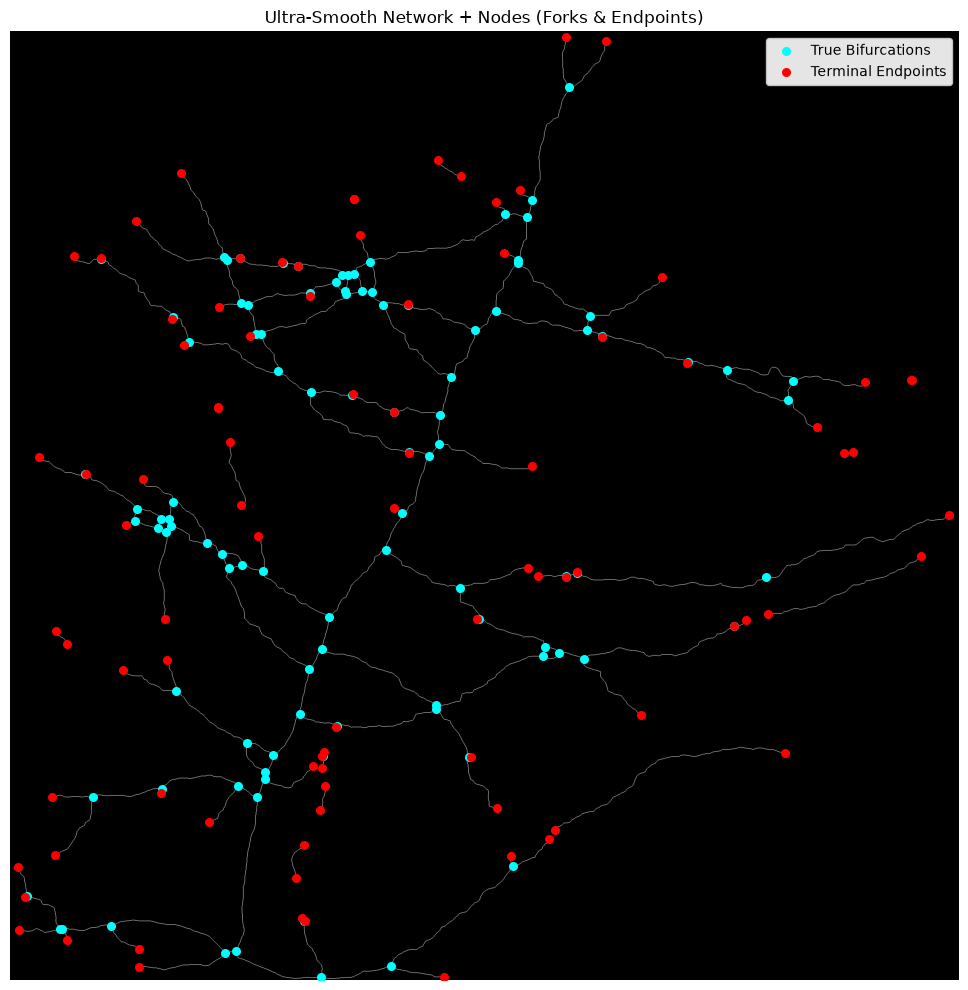

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize, binary_dilation, disk
from scipy.ndimage import convolve, label, center_of_mass

def dilate_reskeletonize_and_find_nodes(pruned_skeleton):
    print("Applying topological string-pull (Dilate -> Re-skeletonize)...")
    
    # 1. INFLATE: Dilate the jagged skeleton into a uniform tube.
    dilated_paths = binary_dilation(pruned_skeleton, disk(3))
    
    # 2. PULL TAUT: Find the pristine, dead-center line of the new smooth tubes.
    ultra_smooth_skeleton = skeletonize(dilated_paths)
    
    print("Running convolution kernel...")
    # Kernel: Center = 10, Neighbors = 1
    kernel = np.array([[1, 1, 1], 
                       [1, 10, 1], 
                       [1, 1, 1]])
    
    neighbor_count = convolve(ultra_smooth_skeleton.astype(int), kernel, mode='constant')
    
    # --- ENDPOINT DETECTION ---
    print("Extracting terminal endpoints...")
    # An endpoint has exactly 1 neighbor (10 + 1 = 11)
    endpoints_mask = (neighbor_count == 11) & ultra_smooth_skeleton
    endpoints_coords = np.argwhere(endpoints_mask)
    
    # --- BIFURCATION DETECTION ---
    # Isolate the raw, noisy fork pixels
    raw_fork_mask = (neighbor_count >= 13) & ultra_smooth_skeleton
    
    print("Clustering topological nodes...")
    # Groups adjacent false-positive pixels into single identifiable clusters
    labeled_forks, num_forks = label(raw_fork_mask)
    
    # Collapse the clusters
    centroids = center_of_mass(raw_fork_mask, labeled_forks, range(1, num_forks + 1))
    true_fork_coords = np.array(centroids) if num_forks > 0 else np.empty((0, 2))
    
    print(f"Found {len(endpoints_coords)} endpoints and {len(true_fork_coords)} true bifurcations.")
    
    return ultra_smooth_skeleton, true_fork_coords, endpoints_coords

# --- Execution ---
# Pass your aggressively pruned skeleton into this new pipeline
smooth_skeleton, true_forks, endpoints = dilate_reskeletonize_and_find_nodes(clean_skeleton)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(smooth_skeleton, cmap='gray')

# Plot the bifurcations in Cyan
if len(true_forks) > 0:
    ax.scatter(true_forks[:, 1], true_forks[:, 0], color='cyan', s=30, zorder=5, label='True Bifurcations')

# Plot the endpoints in Red
if len(endpoints) > 0:
    ax.scatter(endpoints[:, 1], endpoints[:, 0], color='red', s=30, zorder=6, label='Terminal Endpoints')

ax.set_title('Ultra-Smooth Network + Nodes (Forks & Endpoints)')
ax.legend(loc='upper right', framealpha=0.9)
ax.axis('off')

plt.tight_layout()
plt.show()

Shaving microscopic dilation artifacts...
Locating topological nodes...
Severing graph at precise nodes...
Labeling and extracting segments...


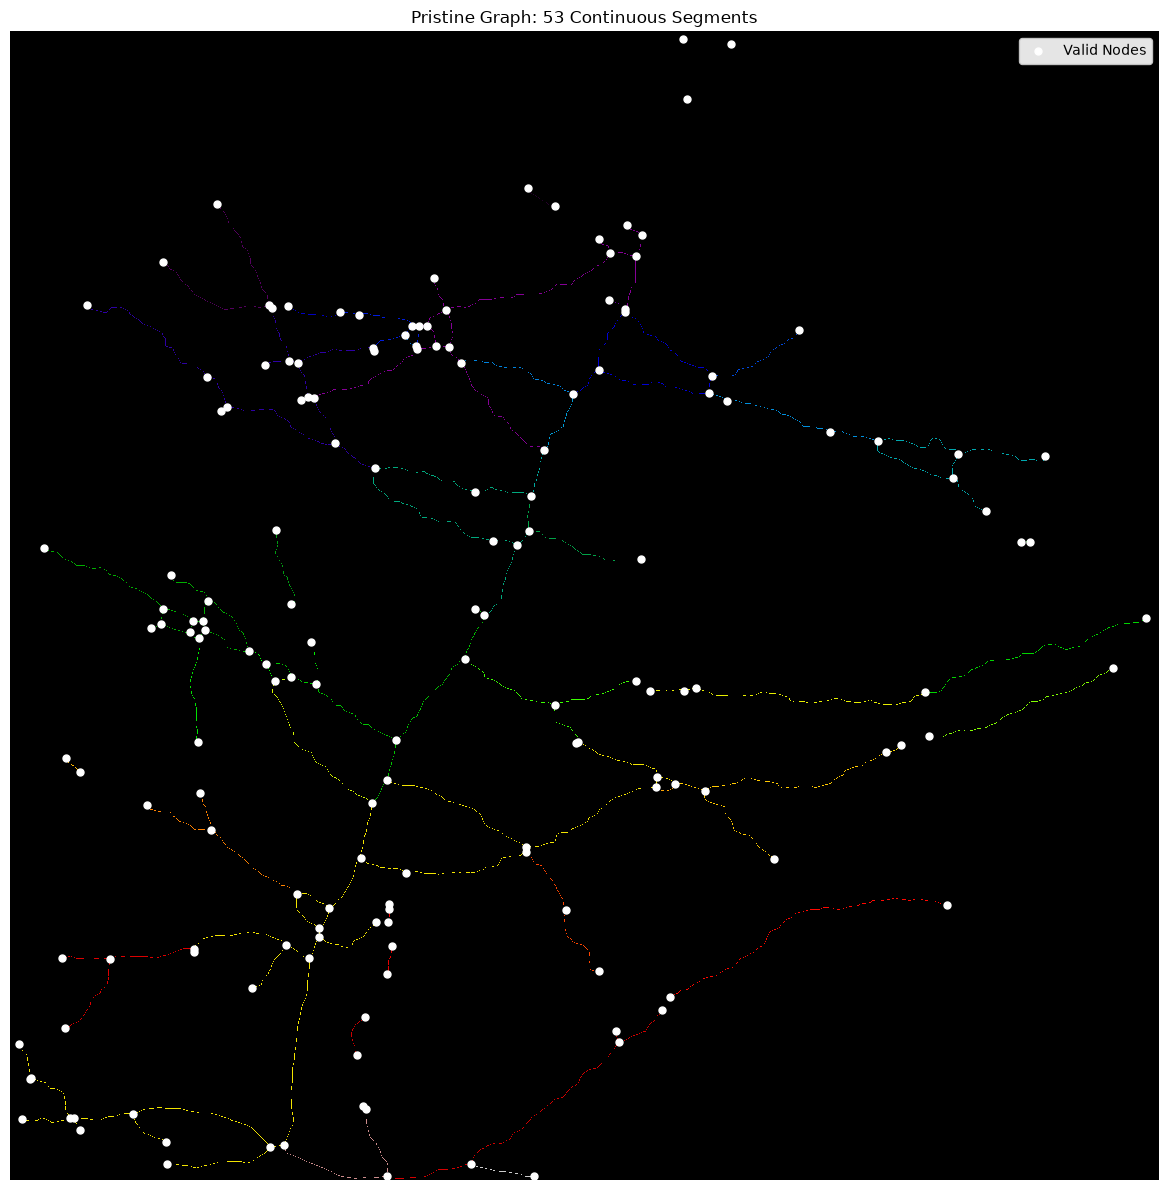

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, label, center_of_mass
from skimage.measure import regionprops

def extract_clean_graph(smooth_skeleton):
    # 1. MICRO-PRUNE (Kill the barbs)
    print("Shaving microscopic dilation artifacts...")
    clean_skeleton = smooth_skeleton.copy()
    kernel = np.array([[1, 1, 1], [1, 10, 1], [1, 1, 1]])
    
    # 2 iterations is enough to erase the 1-pixel barbs 
    # without affecting the true structural branches.
    for _ in range(2):
        nc = convolve(clean_skeleton.astype(int), kernel, mode='constant')
        eps = (nc == 11) & clean_skeleton
        clean_skeleton[eps] = False

    # 2. LOCATE TRUE NODES
    print("Locating topological nodes...")
    nc = convolve(clean_skeleton.astype(int), kernel, mode='constant')
    
    # Endpoints
    endpoints_coords = np.argwhere((nc == 11) & clean_skeleton)
    
    # Cluster the forks down to a single exact pixel
    raw_fork_mask = (nc >= 13) & clean_skeleton
    labeled_forks, num_forks = label(raw_fork_mask)
    centroids = center_of_mass(raw_fork_mask, labeled_forks, range(1, num_forks + 1))
    true_forks = np.array(centroids) if num_forks > 0 else np.empty((0, 2))

    # 3. SEVER NETWORK SAFELY
    print("Severing graph at precise nodes...")
    strict_fork_mask = np.zeros_like(clean_skeleton, dtype=bool)
    
    if len(true_forks) > 0:
        forks_int = np.round(true_forks).astype(int)
        forks_int[:, 0] = np.clip(forks_int[:, 0], 0, clean_skeleton.shape[0]-1)
        forks_int[:, 1] = np.clip(forks_int[:, 1], 0, clean_skeleton.shape[1]-1)
        strict_fork_mask[forks_int[:, 0], forks_int[:, 1]] = True
        
    # Subtract ONLY the 1-pixel junctions so the segments remain continuous
    segments_mask = clean_skeleton & ~strict_fork_mask

    # 4. MEASURE
    print("Labeling and extracting segments...")
    labeled_segments, num_segments = label(segments_mask, structure=np.ones((3,3)))
    
    # Unified nodes for plotting
    all_nodes_y = np.concatenate([true_forks[:, 0], endpoints_coords[:, 0]]) if len(true_forks) > 0 else endpoints_coords[:, 0]
    all_nodes_x = np.concatenate([true_forks[:, 1], endpoints_coords[:, 1]]) if len(true_forks) > 0 else endpoints_coords[:, 1]
    unified_nodes = np.column_stack((all_nodes_y, all_nodes_x))
    
    return clean_skeleton, labeled_segments, num_segments, unified_nodes

# --- Execution ---
barb_free_skeleton, labeled_segments, num_segments, all_nodes = extract_clean_graph(smooth_skeleton)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 12))

cmap = plt.get_cmap('nipy_spectral').copy()
cmap.set_bad(color='black')

masked_segments = np.ma.masked_where(labeled_segments == 0, labeled_segments)

# Plot the beautifully long, continuous segments
ax.imshow(masked_segments, cmap=cmap, interpolation='none')

# Plot the nodes
if len(all_nodes) > 0:
    ax.scatter(all_nodes[:, 1], all_nodes[:, 0], color='white', s=25, zorder=5, label='Valid Nodes')

ax.set_title(f'Pristine Graph: {num_segments} Continuous Segments')
ax.legend(loc='upper right', framealpha=0.9)
ax.axis('off')

plt.tight_layout()
plt.show()

Thickening lines for visualization display...


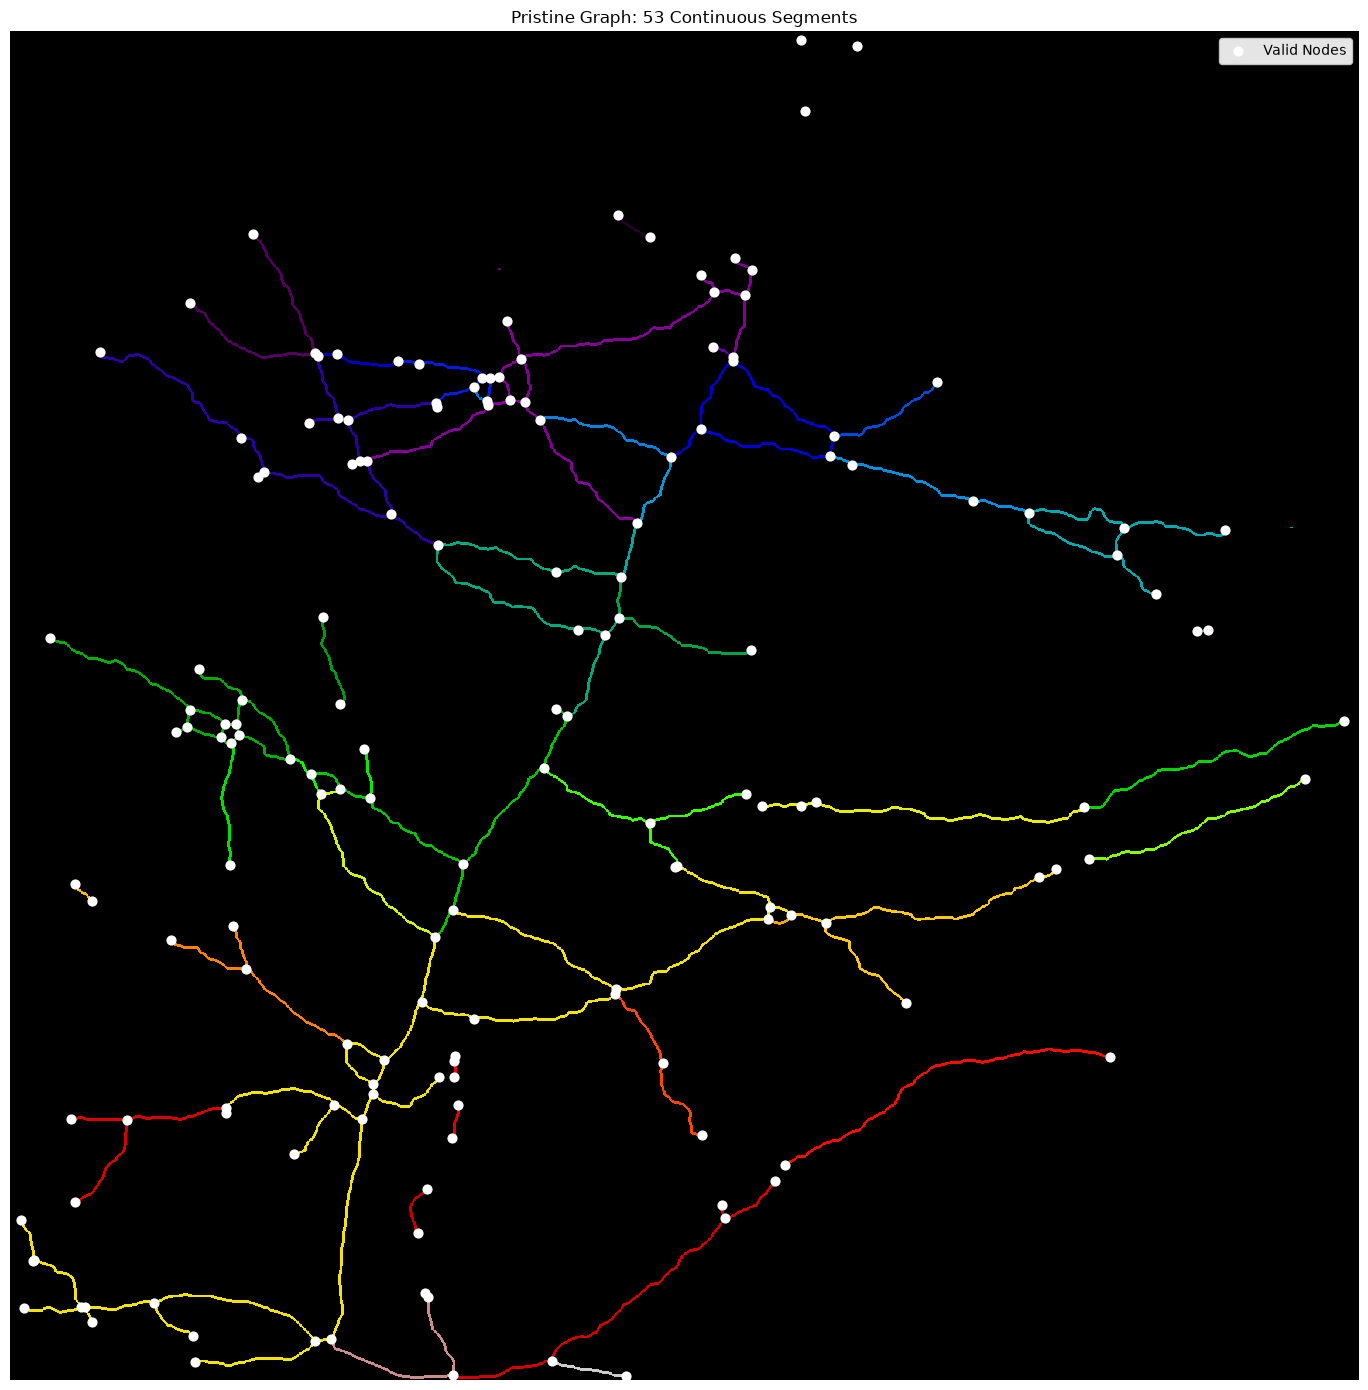

In [12]:
from skimage.morphology import dilation, disk

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 14))

cmap = plt.get_cmap('nipy_spectral').copy()
cmap.set_bad(color='black')

print("Thickening lines for visualization display...")
# 1. THE FIX: We dilate the colored segments by 2 pixels purely for the monitor. 
# This does NOT change your length calculations or data, it just makes the lines visible.
visual_segments = dilation(labeled_segments, disk(2))

# Mask out the background (0)
masked_visuals = np.ma.masked_where(visual_segments == 0, visual_segments)

# Plot the thickened, continuous segments
ax.imshow(masked_visuals, cmap=cmap, interpolation='nearest')

# Plot the nodes
if len(all_nodes) > 0:
    ax.scatter(all_nodes[:, 1], all_nodes[:, 0], color='white', s=40, zorder=5, label='Valid Nodes')

ax.set_title(f'Pristine Graph: {num_segments} Continuous Segments')
ax.legend(loc='upper right', framealpha=0.9)
ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tifffile
from scipy.ndimage import convolve, label, center_of_mass
from skimage.segmentation import expand_labels
from skimage.measure import regionprops
from matplotlib.colors import ListedColormap

def extract_and_heal_graph(smooth_skeleton):
    print("Shaving microscopic dilation artifacts...")
    clean_skeleton = smooth_skeleton.copy()
    kernel = np.array([[1, 1, 1], [1, 10, 1], [1, 1, 1]])
    
    # Prune 1-pixel barbs
    for _ in range(2):
        nc = convolve(clean_skeleton.astype(int), kernel, mode='constant')
        eps = (nc == 11) & clean_skeleton
        clean_skeleton[eps] = False

    print("Locating topological nodes...")
    nc = convolve(clean_skeleton.astype(int), kernel, mode='constant')
    endpoints_coords = np.argwhere((nc == 11) & clean_skeleton)
    
    raw_fork_mask = (nc >= 13) & clean_skeleton
    labeled_forks, num_forks = label(raw_fork_mask)
    centroids = center_of_mass(raw_fork_mask, labeled_forks, range(1, num_forks + 1))
    true_forks = np.array(centroids) if num_forks > 0 else np.empty((0, 2))

    print("Severing graph securely...")
    # THE FIX: Subtract the ENTIRE fork cluster. This guarantees 100% separation.
    shattered_mask = clean_skeleton & ~raw_fork_mask
    
    print("Labeling isolated segments...")
    labeled_segments, num_segments = label(shattered_mask, structure=np.ones((3,3)))
    
    print("Healing the visual gaps mathematically...")
    # 1. Grow the severed labels across the empty gaps
    healed_labels = expand_labels(labeled_segments, distance=3)
    # 2. Multiply by the clean skeleton to restrict the IDs perfectly to the 1-pixel line footprint
    final_labeled_skeleton = healed_labels * clean_skeleton

    all_nodes_y = np.concatenate([true_forks[:, 0], endpoints_coords[:, 0]]) if len(true_forks) > 0 else endpoints_coords[:, 0]
    all_nodes_x = np.concatenate([true_forks[:, 1], endpoints_coords[:, 1]]) if len(true_forks) > 0 else endpoints_coords[:, 1]
    unified_nodes = np.column_stack((all_nodes_y, all_nodes_x))
    
    return final_labeled_skeleton, num_segments, unified_nodes

# --- Execution ---
healed_labeled_skeleton, num_segments, all_nodes = extract_and_heal_graph(smooth_skeleton)

# --- Plotting & Data Extraction ---
fig, ax = plt.subplots(figsize=(16, 16))

# Discontinuous Colormap
np.random.seed(42)
random_colors = np.random.rand(num_segments + 1, 3)
random_colors[0] = [0, 0, 0] 
discontinuous_cmap = ListedColormap(random_colors)

print("Thickening lines strictly for the monitor display...")
visual_segments = expand_labels(healed_labeled_skeleton, distance=2)
masked_visuals = np.ma.masked_where(visual_segments == 0, visual_segments)

ax.imshow(masked_visuals, cmap=discontinuous_cmap, interpolation='nearest', vmin=0, vmax=3))

segment_data = []
props = regionprops(healed_labeled_skeleton)

for prop in props:
    seg_id = prop.label
    length_px = prop.area
    
    # THE TEXT FIX: Find the actual skeleton pixel closest to the mathematical centroid
    geom_center = prop.centroid
    distances = np.sum((prop.coords - geom_center)**2, axis=1)
    mid_y, mid_x = prop.coords[np.argmin(distances)]
    
    ax.text(mid_x, mid_y, str(seg_id), color='white', fontsize=9, 
            fontweight='bold', ha='center', va='center', 
            bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=1.2))
    
    segment_data.append({"Segment_ID": seg_id, "Length_px": length_px})

if len(all_nodes) > 0:
    ax.scatter(all_nodes[:, 1], all_nodes[:, 0], color='white', s=40, zorder=5, label='Topological Nodes')

ax.set_title(f'Healed Graph: {num_segments} Indexed Segments (No Fusions)')
ax.legend(loc='upper right', framealpha=0.9)
ax.axis('off')

plt.tight_layout()
plt.show()

# --- Export ---
df_segments = pd.DataFrame(segment_data)
print("\n--- Segment Measurement Table (First 15 Rows) ---")
print(df_segments.head(15).to_string(index=False)) 

tifffile.imwrite("labeled_segment_mask.tif", healed_labeled_skeleton.astype(np.uint16))
df_segments.to_csv("segment_measurements.csv", index=False)
print("\nSaved 'labeled_segment_mask.tif' and 'segment_measurements.csv'.")

SyntaxError: unmatched ')' (2582881807.py, line 65)

Filtering out segments shorter than 100 pixels...
Kept 71 major segments.
Thickening lines strictly for the monitor display...


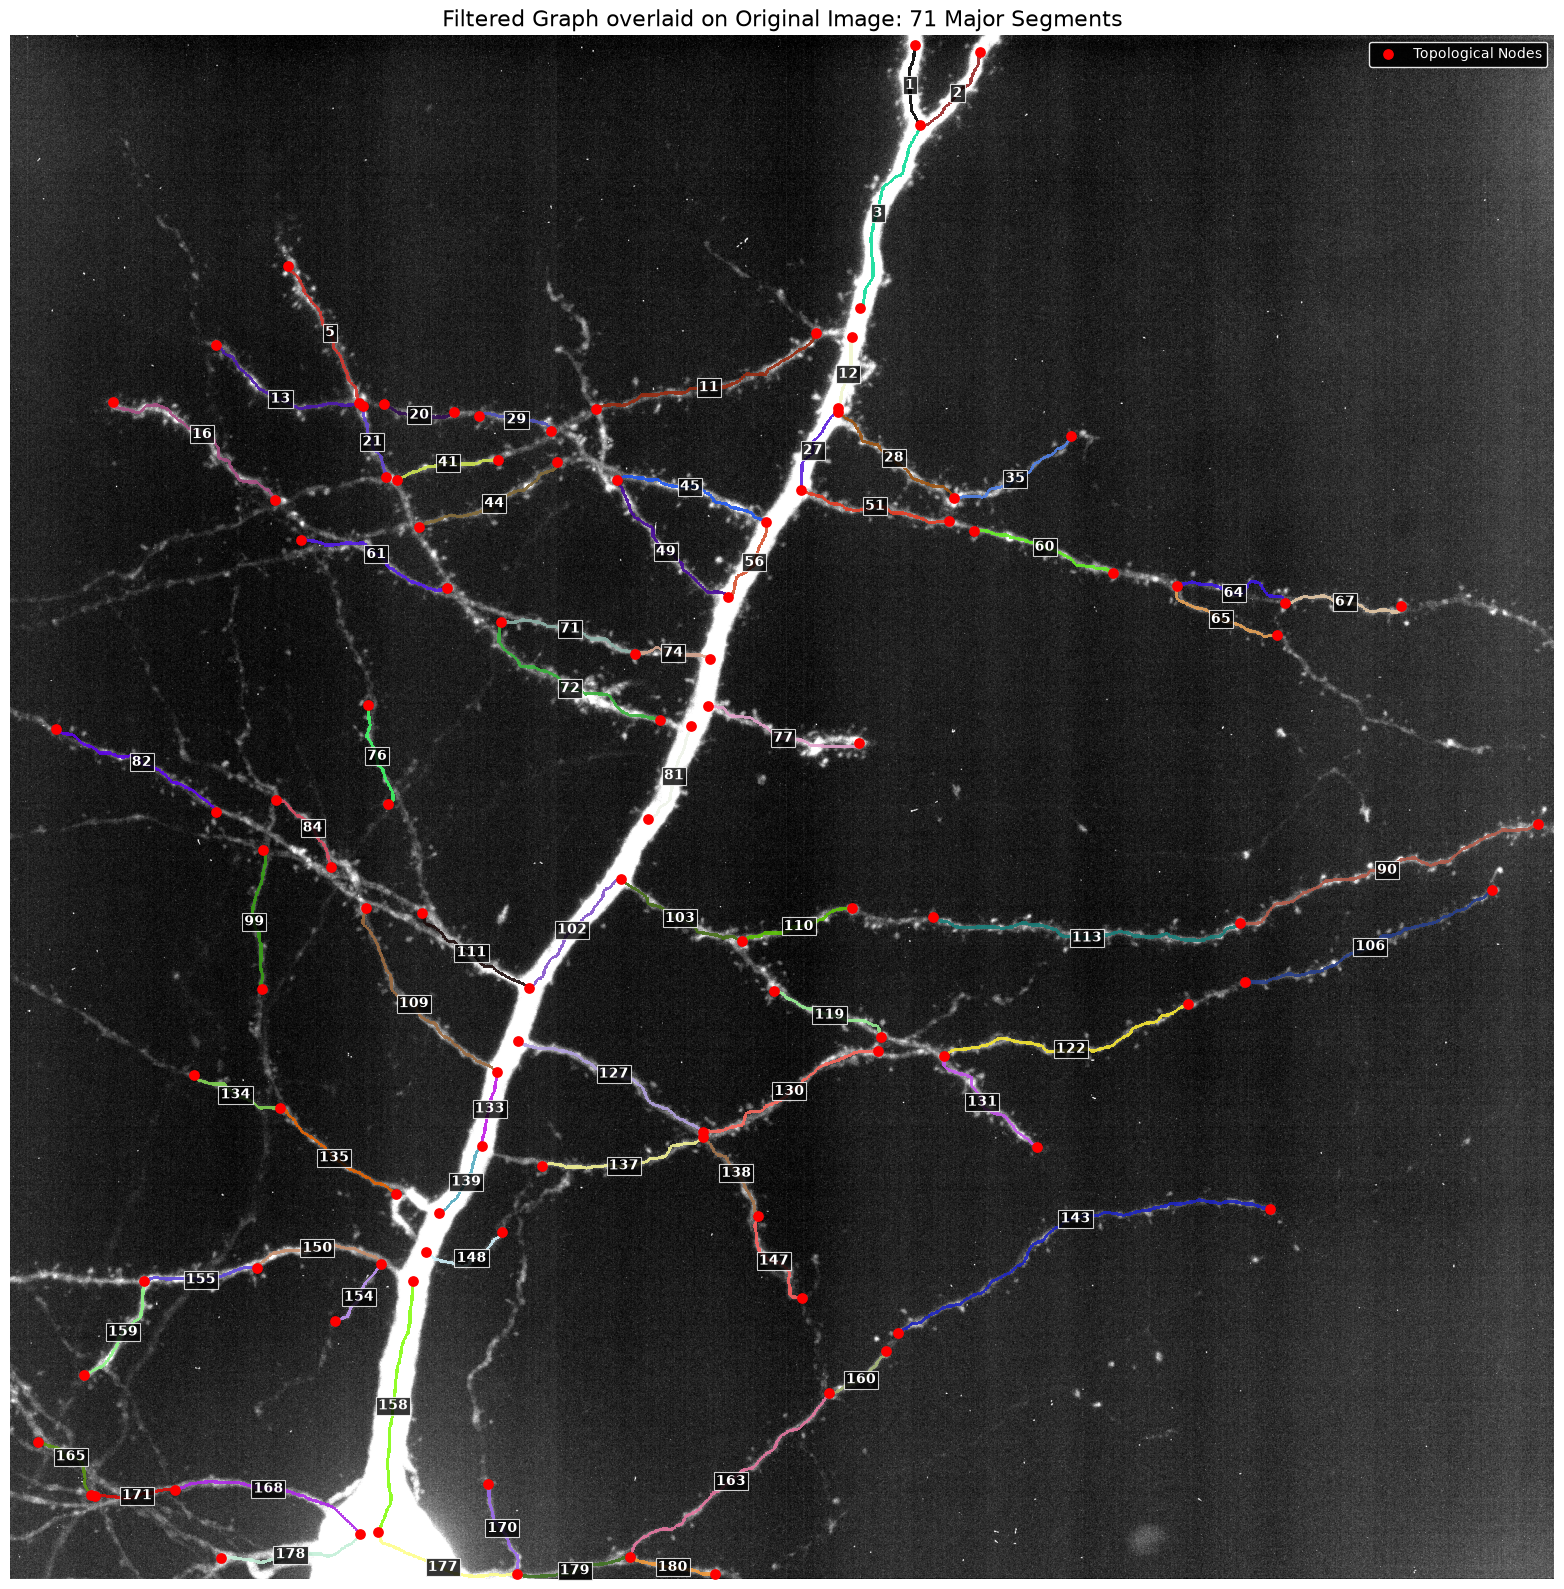


--- Filtered Segment Measurement Table (Sorted by Size) ---
 Segment_ID  Length_px
        143      579.0
        113      464.0
         90      454.0
        106      375.0
        158      374.0
        122      372.0
         11      344.0
        163      342.0
        109      300.0
         72      293.0
        127      291.0
         16      288.0
          3      285.0
        130      282.0
        168      277.0
        137      247.0
         82      247.0
         13      230.0
         49      230.0
         77      229.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.segmentation import expand_labels
from skimage.measure import regionprops
from matplotlib.colors import ListedColormap

# ==========================================
# --- USER DEFINED VARIABLE ---
# ==========================================
MIN_LENGTH_THRESHOLD = 100
# ==========================================

print(f"Filtering out segments shorter than {MIN_LENGTH_THRESHOLD} pixels...")

# 1. Analyze and filter the healed skeleton
props = regionprops(healed_labeled_skeleton)
valid_segment_ids = [prop.label for prop in props if prop.area >= MIN_LENGTH_THRESHOLD]

filtered_labeled_skeleton = np.where(
    np.isin(healed_labeled_skeleton, valid_segment_ids), 
    healed_labeled_skeleton, 
    0
)

num_filtered_segments = len(valid_segment_ids)
print(f"Kept {num_filtered_segments} major segments.")

# --- Plotting Overlay on Original Image ---
fig, ax = plt.subplots(figsize=(16, 16))

# 1. BASE LAYER: The original grayscale image
# Calculate percentiles for optimal contrast display
p_low, p_high = np.percentile(mip, 2), np.percentile(mip, 98)
ax.imshow(mip, cmap='gray', vmin=p_low, vmax=p_high)

# 2. OVERLAY LAYER: The colored segments
np.random.seed(42)
max_id = np.max(healed_labeled_skeleton)
random_colors = np.random.rand(max_id + 1, 3)
random_colors[0] = [0, 0, 0] # Background is 0
discontinuous_cmap = ListedColormap(random_colors)

print("Thickening lines strictly for the monitor display...")
visual_segments = expand_labels(filtered_labeled_skeleton, distance=2)
# Masking the 0s makes them transparent, allowing the 'mip' image to show through
masked_visuals = np.ma.masked_where(visual_segments == 0, visual_segments)

# Plot segments with a slight transparency (alpha=0.9) so underlying structures are faintly visible
ax.imshow(masked_visuals, cmap=discontinuous_cmap, interpolation='nearest', alpha=0.9)

segment_data = []
filtered_props = regionprops(filtered_labeled_skeleton)

for prop in filtered_props:
    seg_id = prop.label
    length_px = prop.area
    
    # Locate the exact midpoint pixel of the segment
    geom_center = prop.centroid
    distances = np.sum((prop.coords - geom_center)**2, axis=1)
    mid_y, mid_x = prop.coords[np.argmin(distances)]
    
    # High-contrast text label
    ax.text(mid_x, mid_y, str(seg_id), color='white', fontsize=10, 
            fontweight='bold', ha='center', va='center', 
            bbox=dict(facecolor='black', alpha=0.8, edgecolor='white', pad=1.5, linewidth=0.8))
    
    segment_data.append({"Segment_ID": seg_id, "Length_px": length_px})

# Overlay the Nodes
if len(all_nodes) > 0:
    valid_nodes = []
    for node in all_nodes:
        y, x = int(node[0]), int(node[1])
        y_min, y_max = max(0, y-2), min(filtered_labeled_skeleton.shape[0], y+3)
        x_min, x_max = max(0, x-2), min(filtered_labeled_skeleton.shape[1], x+3)
        if np.any(filtered_labeled_skeleton[y_min:y_max, x_min:x_max] > 0):
            valid_nodes.append(node)
    
    if valid_nodes:
        valid_nodes = np.array(valid_nodes)
        ax.scatter(valid_nodes[:, 1], valid_nodes[:, 0], color='red', s=45, zorder=5, label='Topological Nodes')

ax.set_title(f'Filtered Graph overlaid on Original Image: {num_filtered_segments} Major Segments', color='black', fontsize=16)

# Legend styling
legend = ax.legend(loc='upper right', framealpha=0.9, facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')

ax.axis('off')
plt.tight_layout()
plt.show()

# --- Display Filtered Table ---
df_filtered_segments = pd.DataFrame(segment_data)
df_filtered_segments = df_filtered_segments.sort_values(by="Length_px", ascending=False).reset_index(drop=True)

print("\n--- Filtered Segment Measurement Table (Sorted by Size) ---")
print(df_filtered_segments.head(20).to_string(index=False))

In [ ]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


Scanning for the brightest 20x20 region...
Extracting segment properties and intensities...
Clustering segments into Low, Medium, and High intensity...
Safely thickening unique segments to preserve topological gaps...


c:\Users\vaiss\anaconda3\envs\IntSpine\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


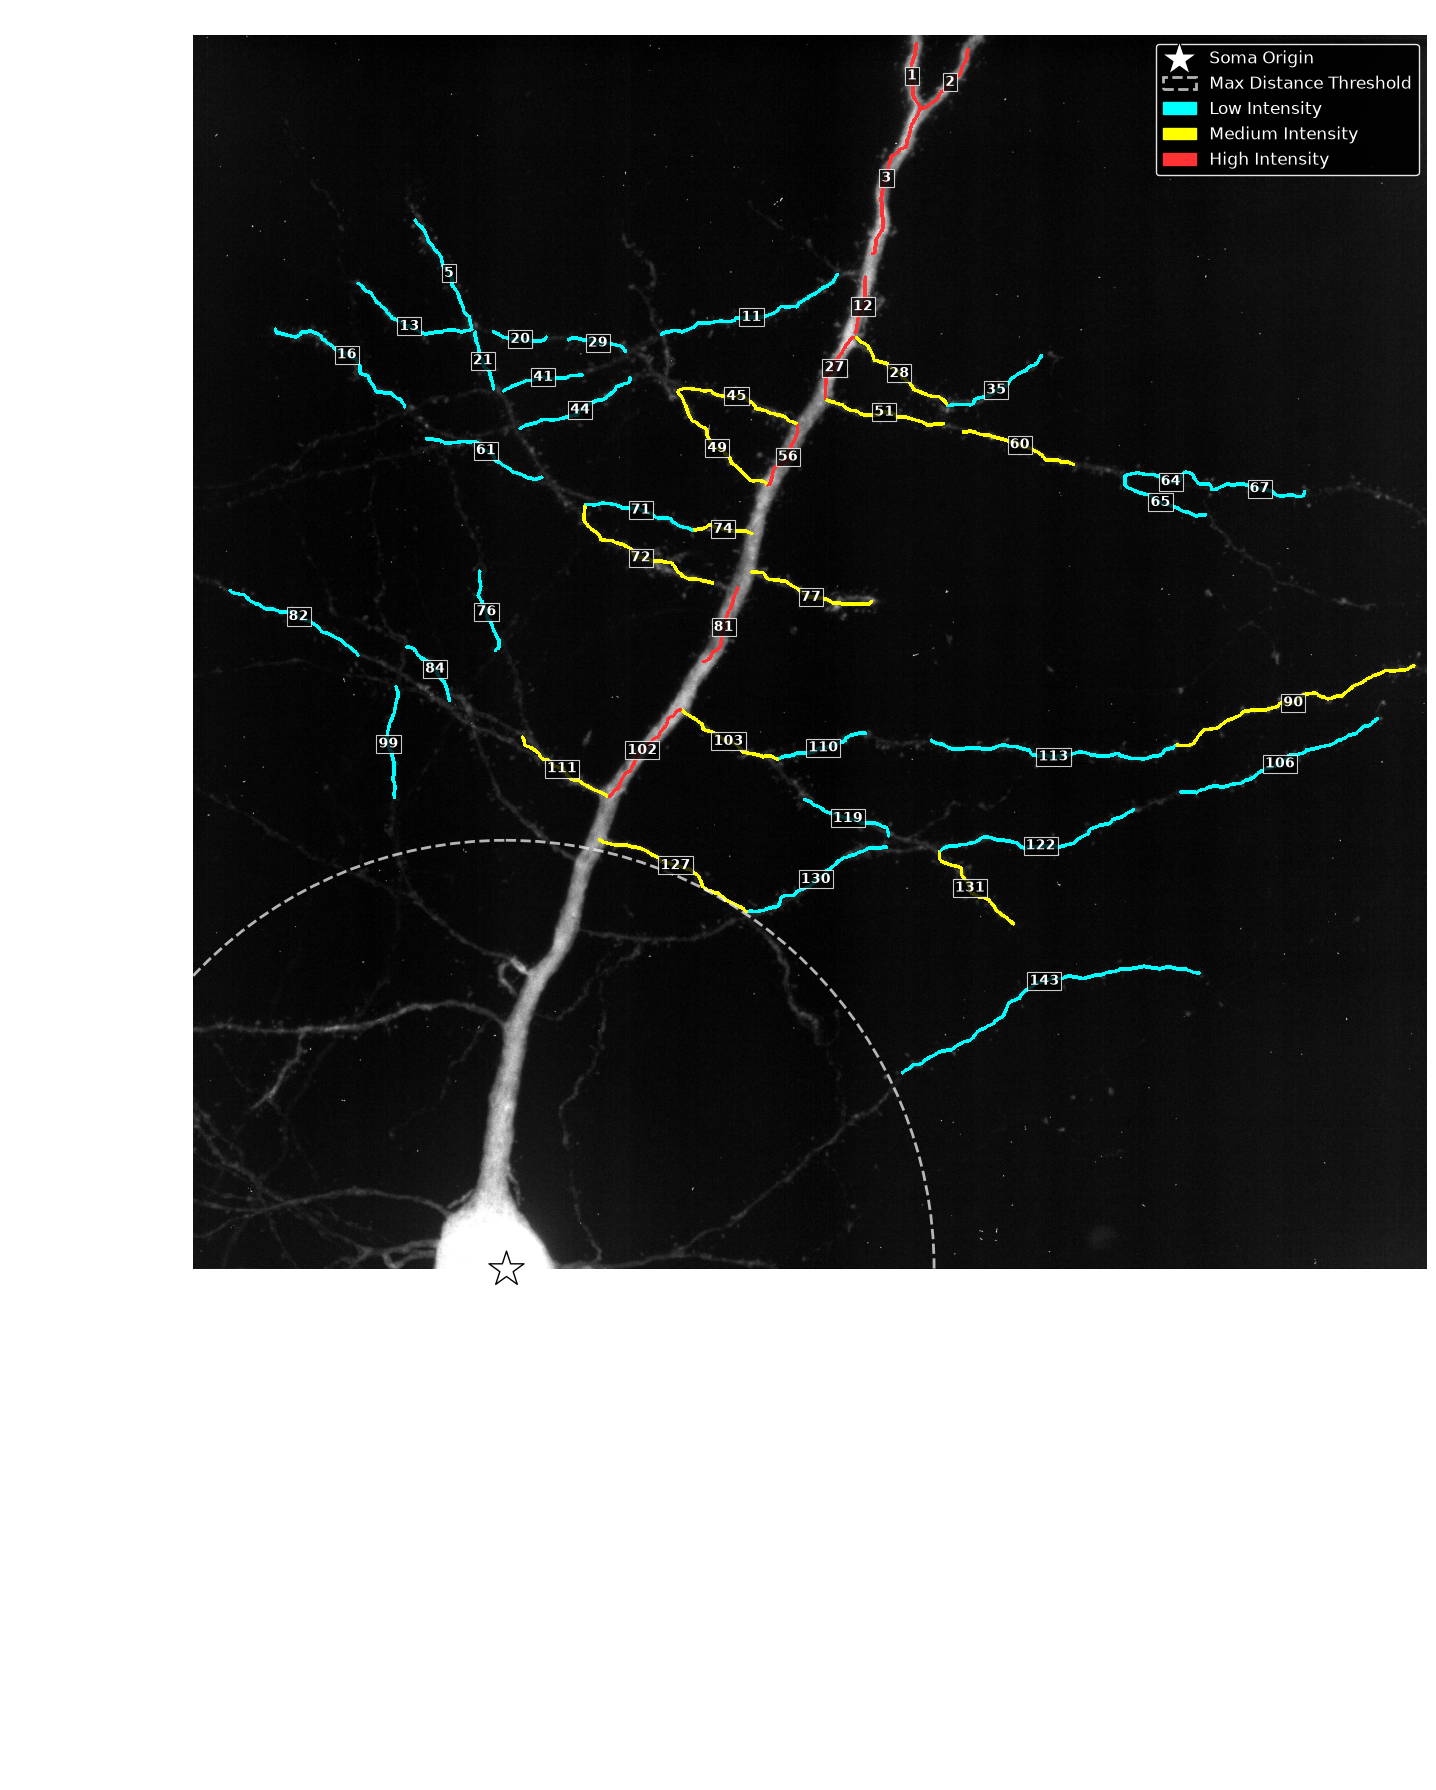


--- Segment Measurement Table (Sorted by Intensity) ---
 Segment_ID  Length_px  Distance_to_Soma_px  Mean_Intensity Intensity_Class
         27      121.0              1730.26          376.02            High
        102      190.0               902.66          360.83            High
          3      285.0              2015.95          360.01            High
         12      108.0              1865.64          359.36            High
          1      121.0              2302.02          351.60            High
         81      149.0              1192.53          325.51            High
         56      128.0              1543.19          325.09            High
          2      133.0              2302.36          320.33            High
        111      181.0               902.23          222.14          Medium
         45      229.0              1668.49          206.48          Medium
        103      191.0              1060.92          205.64          Medium
         72      293.0         

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.segmentation import expand_labels
from skimage.measure import regionprops
from scipy.ndimage import uniform_filter
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

# ==========================================
# --- USER DEFINED VARIABLES ---
# ==========================================
MIN_LENGTH_THRESHOLD = 50 
MAX_SOMA_DISTANCE_PX = 800  
SOMA_WINDOW_SIZE = 20
# ==========================================

# 1. FIND THE SOMA
print(f"Scanning for the brightest {SOMA_WINDOW_SIZE}x{SOMA_WINDOW_SIZE} region...")
local_means = uniform_filter(mip.astype(float), size=SOMA_WINDOW_SIZE)
soma_y, soma_x = np.unravel_index(np.argmax(local_means), local_means.shape)

# 2. RUN REGIONPROPS WITH THE INTENSITY IMAGE
print("Extracting segment properties and intensities...")
filtered_props = regionprops(filtered_labeled_skeleton, intensity_image=mip)

valid_props = []
intensities = []

for prop in filtered_props:
    if prop.area < MIN_LENGTH_THRESHOLD:
        continue
    
    dists_to_soma = np.sqrt((prop.coords[:, 0] - soma_y)**2 + (prop.coords[:, 1] - soma_x)**2)
    min_dist_to_soma = np.min(dists_to_soma)
    
    if min_dist_to_soma >= MAX_SOMA_DISTANCE_PX:
        valid_props.append({
            "prop": prop,
            "soma_dist": min_dist_to_soma,
            "mean_intensity": prop.intensity_mean
        })
        intensities.append(prop.intensity_mean)

# 3. K-MEANS CLUSTERING (3 Groups)
print("Clustering segments into Low, Medium, and High intensity...")
intensities_array = np.array(intensities).reshape(-1, 1)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
raw_labels = kmeans.fit_predict(intensities_array)

sorted_centers_idx = np.argsort(kmeans.cluster_centers_.flatten())
label_mapping = {old_label: new_label for new_label, old_label in enumerate(sorted_centers_idx)}
cluster_names = {0: "Low", 1: "Medium", 2: "High"}

# --- THE FIX: PRESERVE BOUNDARIES ---
print("Safely thickening unique segments to preserve topological gaps...")
# Thicken the unique IDs FIRST so they don't fuse together
visual_segments = expand_labels(filtered_labeled_skeleton, distance=3)

# Create a blank canvas for the intensity colors
visual_cluster_mask = np.zeros_like(visual_segments)
segment_data = []

# Map the colors onto the thickened shapes
for i, data in enumerate(valid_props):
    prop = data["prop"]
    seg_id = prop.label
    cluster_id = label_mapping[raw_labels[i]]
    
    # Apply the cluster color (1, 2, or 3) ONLY where this specific thickened segment exists
    visual_cluster_mask[visual_segments == seg_id] = cluster_id + 1
    
    segment_data.append({
        "Segment_ID": seg_id, 
        "Length_px": prop.area,
        "Distance_to_Soma_px": round(data["soma_dist"], 2),
        "Mean_Intensity": round(data["mean_intensity"], 2),
        "Intensity_Class": cluster_names[cluster_id]
    })

# --- Plotting Overlay on Original Image ---
fig, ax = plt.subplots(figsize=(18, 18))

# BASE LAYER: The original grayscale image (Dimmed slightly by raising vmax so colors pop)
p_low, p_high = np.percentile(mip, 2), np.percentile(mip, 99.5)
ax.imshow(mip, cmap='gray', vmin=p_low, vmax=p_high * 1.2)

# OVERLAY LAYER: 3-Color Intensity Colormap
custom_colors = [
    [0, 0, 0, 0],         # 0 - Background (Transparent)
    [0, 1, 1, 1.0],       # 1 - Low (Cyan)
    [1, 1, 0, 1.0],       # 2 - Medium (Yellow)
    [1, 0.2, 0.2, 1.0]    # 3 - High (Red)
]
intensity_cmap = ListedColormap(custom_colors)

# Mask the 0s so the MIP shows through
masked_visuals = np.ma.masked_where(visual_cluster_mask == 0, visual_cluster_mask)

# Plot the cleanly separated intensity clusters
ax.imshow(masked_visuals, cmap=intensity_cmap, interpolation='nearest', vmin=0, vmax=3)

# Add the Text Labels
for data in valid_props:
    prop = data["prop"]
    seg_id = prop.label
    
    geom_center = prop.centroid
    distances_to_center = np.sum((prop.coords - geom_center)**2, axis=1)
    mid_y, mid_x = prop.coords[np.argmin(distances_to_center)]
    
    ax.text(mid_x, mid_y, str(seg_id), color='white', fontsize=10, 
            fontweight='bold', ha='center', va='center', 
            bbox=dict(facecolor='black', alpha=0.8, edgecolor='white', pad=1.5, linewidth=0.8))

# Overlay the Soma location
ax.scatter(soma_x, soma_y, color='white', marker='*', s=700, edgecolors='black', zorder=10, label='Soma Origin')

# Draw the Max Distance Radius
soma_radius = plt.Circle((soma_x, soma_y), MAX_SOMA_DISTANCE_PX, color='white', fill=False, linestyle='--', linewidth=2, alpha=0.7, label='Max Distance Threshold')
ax.add_patch(soma_radius)

# Custom legend handles
import matplotlib.patches as mpatches
low_patch = mpatches.Patch(color=[0, 1, 1], label='Low Intensity')
med_patch = mpatches.Patch(color=[1, 1, 0], label='Medium Intensity')
high_patch = mpatches.Patch(color=[1, 0.2, 0.2], label='High Intensity')

ax.set_title(f'Intensity Classification: {len(segment_data)} Segments Clustered', color='white', fontsize=16)

# Update legend
handles, labels = ax.get_legend_handles_labels()
handles.extend([low_patch, med_patch, high_patch])
legend = ax.legend(handles=handles, loc='upper right', framealpha=0.9, facecolor='black', edgecolor='white', fontsize=12)
for text in legend.get_texts():
    text.set_color('white')

ax.axis('off')
plt.tight_layout()
plt.show()

# --- Display Updated Table ---
df_intensity_segments = pd.DataFrame(segment_data)
df_intensity_segments = df_intensity_segments.sort_values(by="Mean_Intensity", ascending=False).reset_index(drop=True)

print("\n--- Segment Measurement Table (Sorted by Intensity) ---")
print(df_intensity_segments.head(20).to_string(index=False))

In [ ]:
df_intensity_segments.

,Segment_ID,Length_px,Distance_to_Soma_px,Mean_Intensity,Intensity_Class
0,177,218.0,38.28,612.16,High
1,158,374.0,78.72,415.57,Medium
2,139,106.0,548.97,365.39,Medium
3,133,112.0,656.07,346.65,Medium
4,178,208.0,89.10,304.89,Medium
5,168,277.0,90.55,237.78,Low
6,155,167.0,511.81,223.99,Low
7,159,163.0,545.62,210.66,Low
8,150,191.0,471.02,207.95,Low
9,179,169.0,173.14,195.10,Low


This is the exact bridge you need to connect your 2D skeleton analysis to your 3D volumetric extraction.

In [ ]:
import matplotlib.patches as patches
import roifile

# ==========================================
# --- USER DEFINED VARIABLE ---
# ==========================================
# Define how many pixels to expand the bounding box outwards.
# Adjust this to ensure all dendritic spines are captured in the final 3D crop.
BBOX_PADDING_PX = 30 
# ==========================================

fig, ax = plt.subplots(figsize=(18, 18), facecolor='black')

# 1. Base image & Segments
p_low, p_high = np.percentile(mip, 2), np.percentile(mip, 99.5)
ax.imshow(mip, cmap='gray', vmin=p_low, vmax=p_high * 1.2)
ax.imshow(masked_visuals, cmap=intensity_cmap, interpolation='nearest', vmin=0, vmax=3)

roi_list = []
# Get maximum image dimensions to prevent padding from going out-of-bounds
image_max_y, image_max_x = filtered_labeled_skeleton.shape

print(f"Generating padded bounding boxes (Buffer: {BBOX_PADDING_PX}px)...")
props = regionprops(filtered_labeled_skeleton)

for prop in props:
    seg_id = prop.label
    
    # regionprops returns (min_row, min_col, max_row, max_col) which maps to (y1, x1, y2, x2)
    min_y, min_x, max_y_bbox, max_x_bbox = prop.bbox
    
    # Apply padding and strictly clamp to image borders
    top = int(max(0, min_y - BBOX_PADDING_PX))
    bottom = int(min(image_max_y, max_y_bbox + BBOX_PADDING_PX))
    left = int(max(0, min_x - BBOX_PADDING_PX))
    right = int(min(image_max_x, max_x_bbox + BBOX_PADDING_PX))
    
    width = right - left
    height = bottom - top
    
    # Draw the bounding box on the visualization plot
    rect = patches.Rectangle((left, top), width, height, linewidth=1.5, 
                             edgecolor='cyan', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    
    # Add a label to the box
    ax.text(left, top - 5, f"ROI {seg_id}", color='cyan', fontsize=10, fontweight='bold')
    
    # Create the ImageJ-compatible Rectangular ROI
    roi = roifile.ImagejRoi()
    roi.roitype = roifile.ROI_TYPE.RECT
    roi.top = top
    roi.left = left
    roi.bottom = bottom
    roi.right = right
    roi.name = f"Segment_{seg_id}"
    
    roi_list.append(roi)

ax.axis('off')
ax.set_title(f'3D Subvolume Extraction Mapping: {len(roi_list)} Bounding Boxes Generated', color='white', fontsize=16)
plt.tight_layout()
plt.show()

# --- 2. Export to ZIP for ZStackProcessor ---
# Save this file into the base_dir_path that your class expects
export_path = "auto_generated_segment_rois.zip"
roifile.roiwrite(export_path, roi_list)

print(f"Success! Exported {len(roi_list)} ROIs to '{export_path}'")